In [13]:
import numpy as np
from collections import defaultdict, Counter

def calculate_metrics(students: list, challanges: list, assignments: list, careers: list) -> dict:
    """
    Calcula métricas de calidad para una asignación de estudiantes a desafíos

    Args:
        students: Lista de estudiantes con Nombre,Carrera y Postulaciones
        challanges: Lista de desafíos con Título y Carrerras
        assignments: Lista de desafíos asignados a los estudiantes
        careers: Lista de carreras con Nombre y Máximo

    Returns:
        dict: Diccionario con todas las métricas calculadas
    """
    metrics = {}

    # Crear diccionario de equipos
    equipos = defaultdict(list)
    for assignment in assignments:
        equipos[assignment['Desafio']].append(assignment['Nombre'])

    # Diccionario para mapear estudiante a sus postulaciones y carreras
    estudiantes_postulaciones = {s['Nombre']: s['Postulaciones'] for s in students}
    estudiantes_carreras = {s['Nombre']: s['Carrera'] for s in students}

    # Diccionario de límites por carrera
    limites_carreras = {c['Nombre']: c['Maximo'] for c in careers}

    # Calcular satisfacción individual y métricas relacionadas
    satisfacciones = []
    primera_prioridad = 0
    fuera_preferencias = 0

    for assignment in assignments:
        nombre = assignment['Nombre']
        desafio = assignment['Desafio']
        postulaciones = estudiantes_postulaciones[nombre]

        try:
            indice = postulaciones.index(desafio)
            satisfaccion = 1 / (indice + 1)
            if indice == 0:
                primera_prioridad += 1
        except ValueError:
            satisfaccion = 0
            fuera_preferencias += 1

        satisfacciones.append(satisfaccion)

    # Calcular tamaños de equipos y carreras por equipo
    tamanos_equipos = []
    carreras_por_equipo = []
    equipos_por_tamano = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
    equipos_exceden_limite = 0

    for desafio, miembros in equipos.items():
        if len(miembros) > 0:  # Solo considerar equipos con al menos un miembro
            tamano = len(miembros)
            tamanos_equipos.append(tamano)

            # Contar tamaños de equipo
            if tamano >= 5:
                equipos_por_tamano[5] += 1
            else:
                equipos_por_tamano[tamano] += 1

            # Contar carreras en el equipo
            carreras_equipo = Counter(estudiantes_carreras[estudiante] for estudiante in miembros)
            carreras_por_equipo.append(len(carreras_equipo))

            # Verificar límites por carrera
            excede_limite = False
            for carrera, cantidad in carreras_equipo.items():
                if cantidad > limites_carreras.get(carrera, 0):
                    excede_limite = True
                    break
            if excede_limite:
                equipos_exceden_limite += 1

    # Calcular desafíos sin equipo
    desafios_totales = set(c['Titulo'] for c in challanges)
    desafios_asignados = set(equipos.keys())
    desafios_sin_equipo = len(desafios_totales - desafios_asignados)

    # Almacenar métricas
    metrics['satisfaccion_promedio'] = np.mean(satisfacciones)
    metrics['estudiantes_primera_prioridad'] = primera_prioridad
    metrics['estudiantes_fuera_preferencias'] = fuera_preferencias
    metrics['desafios_sin_equipo'] = desafios_sin_equipo
    metrics['std_tamano_equipos'] = np.std(tamanos_equipos)
    metrics['promedio_carreras_por_equipo'] = np.mean(carreras_por_equipo)
    metrics['total_equipos'] = len([eq for eq in equipos.values() if len(eq) > 0])
    metrics['tamano_promedio_equipo'] = np.mean(tamanos_equipos)
    metrics['equipos_tamano_1'] = equipos_por_tamano[1]
    metrics['equipos_tamano_2'] = equipos_por_tamano[2]
    metrics['equipos_tamano_3'] = equipos_por_tamano[3]
    metrics['equipos_tamano_4'] = equipos_por_tamano[4]
    metrics['equipos_tamano_5_o_mas'] = equipos_por_tamano[5]
    metrics['equipos_exceden_limite_carrera'] = equipos_exceden_limite

    # Imprimir resultados
    # print("\n=== Métricas de Asignación ===")
    # print(f"Satisfacción promedio: {metrics['satisfaccion_promedio']:.3f}")
    # print(f"Estudiantes en primera prioridad: {metrics['estudiantes_primera_prioridad']}")
    # print(f"Estudiantes fuera de preferencias: {metrics['estudiantes_fuera_preferencias']}")
    # print(f"Desafíos sin equipo: {metrics['desafios_sin_equipo']}")
    # print(f"Desviación estándar tamaño equipos: {metrics['std_tamano_equipos']:.3f}")
    # print(f"Promedio de carreras por equipo: {metrics['promedio_carreras_por_equipo']:.2f}")

    # print(f"\nDistribución de tamaños de equipo:")
    # print(f"Equipos de 1 estudiante: {metrics['equipos_tamano_1']}")
    # print(f"Equipos de 2 estudiantes: {metrics['equipos_tamano_2']}")
    # print(f"Equipos de 3 estudiantes: {metrics['equipos_tamano_3']}")
    # print(f"Equipos de 4 estudiantes: {metrics['equipos_tamano_4']}")
    # print(f"Equipos de 5 o más estudiantes: {metrics['equipos_tamano_5_o_mas']}")

    # print(f"\nMétricas de límites:")
    # print(f"Equipos que exceden límites por carrera: {metrics['equipos_exceden_limite_carrera']}")

    # print(f"\nMétricas adicionales:")
    # print(f"Total de equipos formados: {metrics['total_equipos']}")
    # print(f"Tamaño promedio de equipo: {metrics['tamano_promedio_equipo']:.2f}")

    return metrics

In [14]:
import logging
from datetime import datetime
import os
import time

# Crear directorio para logs si no existe
log_dir = "logs"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

# Configurar logging con DEBUG habilitado
log_filename = os.path.join(log_dir, f"mcts_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")

# Configurar formato detallado para los logs
log_format = '%(asctime)s - %(levelname)7s - %(message)s'

# Configurar handler para archivo
file_handler = logging.FileHandler(log_filename)
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(logging.Formatter(log_format))

# Configurar handler para consola
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)  # También mostramos DEBUG en consola
console_handler.setFormatter(logging.Formatter(log_format))

# Configurar logger principal
logger = logging.getLogger('MCTS')
logger.setLevel(logging.DEBUG)  # Establecer nivel DEBUG
logger.addHandler(file_handler)
logger.addHandler(console_handler)

# Log inicial para verificar que todo está funcionando
logger.debug('Iniciando sistema de logging en modo DEBUG')
logger.info('Sistema de logging inicializado correctamente')

2024-11-04 00:17:46,150 -   DEBUG - Iniciando sistema de logging en modo DEBUG
2024-11-04 00:17:46,150 -   DEBUG - Iniciando sistema de logging en modo DEBUG
2024-11-04 00:17:46,150 -   DEBUG - Iniciando sistema de logging en modo DEBUG
2024-11-04 00:17:46,155 -    INFO - Sistema de logging inicializado correctamente
2024-11-04 00:17:46,155 -    INFO - Sistema de logging inicializado correctamente
2024-11-04 00:17:46,155 -    INFO - Sistema de logging inicializado correctamente


In [15]:
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple

@dataclass
class Config:
    students: List[Dict]
    challenges: List[Dict]
    careers: List[Dict]
    min_team_size: int = 3
    max_team_size: int = 4

class State:
    def __init__(
        self,
        assignments: Dict,
        available_challanges: Dict,
        incomplete_groups: Dict[str, int] = None,
        career_counts: Dict[str, Dict[str, int]] = None,
        total_students_needed: int = 0
    ):
        # Dict donde key es el desafío y value es la lista con estudiantes dando el desafío
        self.assignments = assignments
        # Ejemplo de estructura:
        # {
        #    "SimCity": ["Matias", "Ignacio"]
        # }

        self.available_challanges = available_challanges # Dict donde key es la carrera y value es la lista de desafíos disponibles
        # Ejemplo de estructura:
        # {
        #    "Ing. Civil Telemática": ["SimCity", "Modelo Acústico"]
        # }

        # Dict donde key es el desafío y value es la cantidad de estudiantes en el grupo
        self.incomplete_groups = incomplete_groups if incomplete_groups is not None else {}
        # Ejemplo de estructura:
        # {
        #    "SimCity": 1
        # }

        # Dict donde:
        # - key externa es el desafío
        # - key interna es la carrera
        # - value es la cantidad de estudiantes de esa carrera en ese desafío
        self.career_counts = career_counts if career_counts is not None else {}
        # Ejemplo de estructura:
        # {
        #     "SimCity": {
        #         "Ing. Civil": 2,
        #         "Arquitectura": 1
        #     }
        # }
        self.total_students_needed = total_students_needed
    def __str__(self):
        return f"Assignments: {self.assignments}"

In [16]:
import math
import random
from copy import deepcopy
from tqdm import tqdm

class Node:
    simulation_counter = 0
    def __init__(
        self,
        config: Config,
        current_student_idx: int = 0,
        state: Optional['State'] = None,
        parent: Optional['Node'] = None,
        is_simulation: bool = False  # Nuevo parámetro para identificar nodos de simulación
        ):
        self.is_simulation = is_simulation
        self.simulation_id = None

        if is_simulation:
            Node.simulation_counter += 1
            self.simulation_id = Node.simulation_counter

        # Configuración global
        self.config = config

        # Índice del estudiante actual que estamos asignando
        self.current_student_idx = current_student_idx

        # Estado actual del nodo
        if state is None:
            # Inicializar estado vacío con todos los desafíos disponibles
            available_challanges = {}
            for career in config.careers:
                available_challanges[career["Nombre"]] = [
                    challenge["Titulo"] for challenge in config.challenges
                ]
            self.state = State({}, available_challanges, {})
            # if not is_simulation:
            #     logger.info("Inicializando nodo raíz con estado vacío")
        else:
            self.state = state

        # Flag para saber si es un nodo terminal
        self.is_terminal: bool = self._check_if_terminal()

        if not self.is_terminal:
            self.current_student = self.config.students[self.current_student_idx]
            self.student_career = self.current_student["Carrera"]

        # Referencia al nodo padre
        self.parent = parent

        # Lista de nodos hijos
        self.children: List[Node] = []

        # Métricas MCTS
        self.visits: int = 0  # Número de veces que se ha visitado este nodo
        self.value: float = 0  # Valor acumulado de las simulaciones

        # Lista de acciones posibles desde este estado
        if not self.is_terminal:
            available_challenges = self.state.available_challanges.get(self.student_career, [])
            valid_challenges = [
                challenge for challenge in available_challenges
                if self._is_action_viable(challenge)
            ]


            # Separar y ordenar por preferencias
            preferred_challenges = []
            other_challenges = []

            student_preferences = self.current_student["Postulaciones"]

            for challenge in valid_challenges:
                if challenge in student_preferences:
                    preference_index = student_preferences.index(challenge)
                    preferred_challenges.append((challenge, preference_index))
                else:
                    other_challenges.append(challenge)

            # Ordenar los desafíos preferidos por índice de preferencia
            preferred_challenges.sort(key=lambda x: x[1])
            preferred_challenges = [challenge for challenge, _ in preferred_challenges]

            # Mezclar aleatoriamente los desafíos no preferidos una sola vez
            random.shuffle(other_challenges)

            # Guardar la lista ordenada de acciones
            self.untried_actions = preferred_challenges + other_challenges

        else:
            self.untried_actions = []

    def apply_action(self, challenge: str) -> 'Node':
        """
        Aplica la acción (asigna el estudiante actual al desafío)
        y retorna un nuevo nodo con el estado actualizado
        """
        # Crear nuevas copias de las estructuras del estado
        new_assignments = self.state.assignments.copy()
        new_available_challanges = {
            career: challenges[:]
            for career, challenges in self.state.available_challanges.items()
        }
        new_incomplete_groups = self.state.incomplete_groups.copy()
        new_career_counts = {
            challenge: counts.copy()
            for challenge, counts in self.state.career_counts.items()
        }

        # 1. Actualizar assignments
        if challenge in new_assignments:
            new_assignments[challenge] = new_assignments[challenge] + [self.current_student["Nombre"]]
        else:
            new_assignments[challenge] = [self.current_student["Nombre"]]

        new_group_size = len(new_assignments[challenge])

        # 2. Actualizar incomplete_groups
        if new_group_size < self.config.min_team_size:
            new_incomplete_groups[challenge] = new_group_size
        else:
            new_incomplete_groups.pop(challenge, None)

        # 3. Actualizar career_counts
        if challenge not in new_career_counts:
            new_career_counts[challenge] = {}

        current_career = self.student_career
        new_career_counts[challenge][current_career] = new_career_counts[challenge].get(current_career, 0) + 1

        # 4. Actualizar available_challanges
        # Si el grupo alcanzó el tamaño máximo, remover el desafío de available_challanges
        if new_group_size >= self.config.max_team_size:
            for career in new_available_challanges:
                if challenge in new_available_challanges[career]:
                    new_available_challanges[career].remove(challenge)
        else:
            # Verificar límites por carrera usando career_counts
            career_max = next(c["Maximo"] for c in self.config.careers
                            if c["Nombre"] == current_career)

            if new_career_counts[challenge][current_career] >= career_max:
                if challenge in new_available_challanges.get(current_career, []):
                    new_available_challanges[current_career].remove(challenge)

        # 5. Actualizar total_students_needed
        new_total_students_needed = self.state.total_students_needed

        if challenge in new_assignments:
            old_group_size = len(new_assignments[challenge]) - 1  # sin contar el nuevo estudiante
            if old_group_size < self.config.min_team_size:
                # Si antes necesitábamos X estudiantes, ahora necesitamos X-1
                new_total_students_needed -= 1
        else:
            # Nuevo grupo incompleto, necesitamos (min_size - 1) más estudiantes
            new_total_students_needed += (self.config.min_team_size - 1)

        # Crear nuevo estado con el career_counts actualizado
        new_state = State(
            new_assignments,
            new_available_challanges,
            new_incomplete_groups,
            new_career_counts,
            new_total_students_needed
        )

        # Crear y retornar nuevo nodo
        new_node = Node(
            config=self.config,
            current_student_idx=self.current_student_idx + 1,
            state=new_state,
            parent=self,
            is_simulation=self.is_simulation
        )

        if self.is_simulation:
            new_node.simulation_id = self.simulation_id  # Heredamos el ID de simulación
        return new_node

    def get_uct_score(self, exploration_constant: float = math.sqrt(2)) -> float:
        """
        Calcula el score UCT (Upper Confidence Bound for Trees) del nodo
        """
        if self.visits == 0:
            return float('inf')  # Nodos no visitados tienen prioridad máxima

        # Componente de explotación
        exploitation = self.value / self.visits

        # Componente de exploración
        exploration = exploration_constant * math.sqrt(math.log(self.parent.visits) / self.visits)

        return exploitation + exploration

    def get_best_child(self, exploration_constant: float = 1.0) -> 'Node':
        """
        Selecciona el mejor hijo basado en el score UCT
        """
        if not self.children:
            raise ValueError("Node has no children")

        return max(self.children, key=lambda child: child.get_uct_score(exploration_constant))

    def _check_if_terminal(self) -> bool:
        """
        Verifica si el nodo actual es terminal:
        - Si ya asignamos al último estudiante
        - Si no hay acciones válidas para el estudiante actual
        """
        # Si ya procesamos todos los estudiantes
        if self.current_student_idx >= len(self.config.students):
            return True

        # Si no hay desafíos disponibles para el estudiante actual
        current_student = self.config.students[self.current_student_idx]
        career = current_student["Carrera"]
        available_challenges = self.state.available_challanges.get(career, [])

        return len(available_challenges) == 0

    # === FASES PRINCIPALES DEL MCTS ===

    def select(self) -> 'Node':
        """
        Selecciona el mejor nodo para expandir usando UCT.
        Desciende por el árbol hasta encontrar:
        - Un nodo terminal
        - Un nodo no completamente expandido (tiene acciones sin probar)
        """
        current = self

        # Mientras el nodo actual no sea terminal y esté completamente expandido
        while not current.is_terminal and current.is_fully_expanded():
            # Si no hay hijos, no podemos seguir descendiendo
            if not current.children:
                break
            # Seleccionar el mejor hijo según UCT
            current = current.get_best_child()

            # logger.info(f"Selección: descendiendo a nodo con estudiante {current.current_student_idx}")
            # time.sleep(0.6)  # Delay para visualización

        return current

    def expand(self) -> Optional['Node']:
        """
        Toma la primera acción no probada (que será la mejor disponible según las preferencias)
        y crea un nuevo nodo hijo.
        """
        if self.is_terminal or not self.untried_actions:
            return None

        # Tomar la primera acción (la mejor según preferencias)
        action = self.untried_actions.pop(0)  # Usamos pop(0) para mantener el orden

        # logger.info(f"Expandiendo: asignando estudiante {self.current_student['Nombre']} al desafío {action}")
        # time.sleep(0.6)  # Delay para visualización

        # Crear nuevo nodo hijo aplicando la acción
        child_node = self.apply_action(action)

        # Agregar el nuevo nodo a la lista de hijos
        self.children.append(child_node)

        return child_node

    def simulate(self) -> float:
        """
        Realiza una simulación desde el estado actual hasta un estado terminal
        y retorna el valor de la simulación
        """
        # Crear una copia del nodo actual para la simulación
        current = Node(
            config=self.config,
            current_student_idx=self.current_student_idx,
            state=deepcopy(self.state),
            parent=None,
            is_simulation=True
        )


        # Realizar movimientos aleatorios hasta llegar a un estado terminal
        action = current.get_random_action()

        while not current.is_terminal:

            current = current.apply_action(action)

            action = current.get_random_action()
            if action is None:  # No hay acciones válidas disponibles
                break

        # Evaluar el estado final
        score = current.evaluate_state()

        return score

    def backpropagate(self, value: float) -> None:
        """Actualiza las estadísticas del nodo y sus padres."""
        current = self

        while current is not None:
            current.visits += 1
            current.value += value
            current = current.parent

    # === FUNCIONES APOYO PARA FASES PRINCIPALES ===

    def is_fully_expanded(self) -> bool:
        """
        Un nodo está completamente expandido cuando todas sus acciones posibles
        han sido probadas (convertidas en nodos hijos)
        """
        return len(self.untried_actions) == 0

    def get_random_action(self) -> Optional[str]:
        """
        En simulación, usa la primera acción disponible de untried_actions
        """
        if not self.untried_actions:
            return None

        if random.random() < 0.7:  # 70% del tiempo usar primera preferencia
            return self.untried_actions[0]
        return random.choice(self.untried_actions)

    def evaluate_state(self) -> float:
        """
        Evalúa qué tan bueno es el estado actual.
        Considera múltiples factores con diferentes pesos.
        """
        if not self.is_terminal:
            return 0.0

        score = 0.0
        assigned_students = sum(len(team) for team in self.state.assignments.values())

        preference_score = 0.0
        if assigned_students > 0:
            preference_matches = 0
            for challenge, team in self.state.assignments.items():
                for student_name in team:
                    student = next(s for s in self.config.students if s["Nombre"] == student_name)
                    if challenge in student["Postulaciones"]:
                        # Dar más peso a las primeras preferencias
                        preference_index = student["Postulaciones"].index(challenge)
                        preference_weight = 1.0 / (preference_index + 1)
                        preference_matches += preference_weight

            preference_score = preference_matches / assigned_students
            score += preference_score

        return score

    def get_most_visited_child(self) -> Optional['Node']:
        """
        Retorna el hijo más visitado.
        Útil para la selección final de la mejor acción después de completar las simulaciones.
        """
        if not self.children:
            return None

        return max(self.children, key=lambda child: child.visits)

    def get_best_action(self, num_simulations: int = 100_000) -> Optional[str]:
        for _ in range(num_simulations):
            leaf = self.select()
            if not leaf.is_terminal:
                leaf = leaf.expand()
                if leaf is None:
                    continue
            value = leaf.simulate()
            leaf.backpropagate(value)

        # Evaluar todos los hijos disponibles
        if not self.children:
            return None

        # Calcular score para cada hijo considerando múltiples factores
        best_score = float('-inf')
        best_action = None

        for child in self.children:
            # Factor 1: Valor promedio de las simulaciones
            simulation_score = child.value / child.visits if child.visits > 0 else 0

            # Factor 2: Prioridad por preferencias del estudiante
            action = None
            for challenge, students in child.state.assignments.items():
                if challenge not in self.state.assignments or \
                len(students) > len(self.state.assignments.get(challenge, [])):
                    action = challenge
                    break

            if action is None:
                continue

            preference_score = 0
            if action in self.current_student["Postulaciones"]:
                preference_index = self.current_student["Postulaciones"].index(action)
                preference_score = 1.0 / (preference_index + 1)  # Mayor score para primeras preferencias

            # Combinar factores con pesos
            total_score = (
                0.4 * simulation_score +  # 40% peso para resultados de simulación
                0.6 * preference_score   # 60% peso para preferencias
            )

            if total_score > best_score:
                best_score = total_score
                best_action = action

        return best_action

    def _is_action_viable(self, challenge: str) -> bool:
        """
        Verifica si tomar esta acción nos deja en un estado viable.
        Prioriza completar grupos incompletos y evalúa si hay suficientes estudiantes.
        """
        remaining_students = len(self.config.students) - self.current_student_idx - 1

        # Verificar límite de carrera
        if challenge in self.state.career_counts:
            current_career_count = self.state.career_counts[challenge].get(self.student_career, 0)
            career_max = next(c["Maximo"] for c in self.config.careers
                            if c["Nombre"] == self.student_career)
            if current_career_count >= career_max:
                return False

        # Si el desafío ya existe en las asignaciones
        if challenge in self.state.assignments:
            current_group_size = len(self.state.assignments[challenge])

            # Si el grupo tiene 1 o 2 estudiantes, es viable automáticamente
            if current_group_size < self.config.min_team_size:
                return True

            # Si el grupo ya tiene 3+ estudiantes
            # Necesitamos calcular si podemos permitir que crezca más
            total_incomplete = sum(self.state.incomplete_groups.values())
            students_needed = total_incomplete * self.config.min_team_size - sum(self.state.incomplete_groups.values())

            # Solo permitimos añadir a grupos completos si hay suficientes estudiantes
            # para completar todos los incompletos
            return remaining_students >= students_needed

        # Si es un nuevo desafío
        else:
            # Calcular estudiantes necesarios incluyendo este nuevo grupo
            total_incomplete = sum(self.state.incomplete_groups.values()) + 1  # +1 por este nuevo grupo
            students_needed = total_incomplete * self.config.min_team_size - (sum(self.state.incomplete_groups.values()) + 1)

            return remaining_students >= students_needed

In [17]:
def mcts_assignment(
    students: List[Dict],
    challanges: List[Dict],
    careers: List[Dict],
    assignments: Optional[List[Dict]] = None,
    num_simulations: int = 1_000
) -> List[Dict]:
    """
    Asigna los estudiantes a desafíos mediante Monte Carlo Tree Search

    Args:
        students: Lista de estudiantes con Nombre, Carrera y Postulaciones
        challanges: Lista de desafíos con Título
        careers: Lista de carreras con Nombre y Máximo
        assignments: Lista opcional de asignaciones previas

    Returns:
        list: Lista de desafíos asignados a los estudiantes
    """
    # Crear la configuración
    config = Config(
        students=students,
        challenges=challanges,
        careers=careers,
        min_team_size=2,
        max_team_size=4
    )

    # Si hay asignaciones previas, crear el estado inicial
    if assignments:
        initial_assignments = {}
        initial_career_counts = {}
        initial_incomplete_groups = {}

        for assignment in assignments:
            challenge = assignment["Desafio"]
            student_name = assignment["Nombre"]

            # Actualizar assignments
            if challenge in initial_assignments:
                initial_assignments[challenge].append(student_name)
            else:
                initial_assignments[challenge] = [student_name]

            # Actualizar career_counts
            if challenge not in initial_career_counts:
                initial_career_counts[challenge] = {}

            student = next(s for s in students if s["Nombre"] == student_name)
            career = student["Carrera"]
            initial_career_counts[challenge][career] = initial_career_counts[challenge].get(career, 0) + 1

            # Actualizar incomplete_groups
            group_size = len(initial_assignments[challenge])
            if group_size < config.min_team_size:
                initial_incomplete_groups[challenge] = group_size

        # Crear available_challanges inicial
        available_challanges = {}
        for career in careers:
            available_challanges[career["Nombre"]] = [
                challenge["Titulo"] for challenge in challanges
            ]
            # Remover desafíos no disponibles
            for challenge, team in initial_assignments.items():
                if len(team) >= config.max_team_size:
                    if challenge in available_challanges[career["Nombre"]]:
                        available_challanges[career["Nombre"]].remove(challenge)
                else:
                    career_count = initial_career_counts[challenge].get(career["Nombre"], 0)
                    if career_count >= career["Maximo"]:
                        if challenge in available_challanges[career["Nombre"]]:
                            available_challanges[career["Nombre"]].remove(challenge)

        initial_state = State(
            initial_assignments,
            available_challanges,
            initial_incomplete_groups,
            initial_career_counts
        )
    else:
        initial_state = None

    # Crear nodo raíz
    root = Node(config=config, state=initial_state)

    # Ejecutar MCTS para cada estudiante no asignado
    current_node = root
    while not current_node.is_terminal:
        # Obtener la mejor acción para el estudiante actual
        best_action = current_node.get_best_action(num_simulations)
        if best_action is None:
            break

        # logger.info(f"[{current_node.current_student_idx + 1}/{len(students)}] {current_node.current_student['Nombre']} -> {best_action}")
        # Aplicar la acción y movernos al siguiente estado
        current_node = current_node.apply_action(best_action)

    # Convertir el estado final al formato de salida requerido
    result = []
    for challenge, team in current_node.state.assignments.items():
        for student_name in team:
            result.append({
                "Nombre": student_name,
                "Desafio": challenge
            })

    return result

In [18]:
import json
with open('body.json', 'r') as file:
    body = json.load(file)

In [19]:
assignment = mcts_assignment(body["estudiantes"], body["desafios"], body["carreras"], num_simulations=1_000)
assignment

[{'Nombre': 'Matias Ignacio Ayala Nanjari',
  'Desafio': 'SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.'},
 {'Nombre': 'Ignacio Andrés Araya Salinas',
  'Desafio': 'SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.'},
 {'Nombre': 'Camila Fernanda Guerrero Bustamante',
  'Desafio': 'SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.'},
 {'Nombre': 'Fernanda Ivonne Viera Castillo    ',
  'Desafio': 'SimCity: Creando una simulación 3D de la ciudad para el estudio de fenómenos naturales.'},
 {'Nombre': 'Simón Josías Cristóbal Álvarez Díaz',
  'Desafio': 'Mobile Water Quality Monitoring for Offshore Fish Farms'},
 {'Nombre': 'Francisco Lopez Figueroa',
  'Desafio': 'Mobile Water Quality Monitoring for Offshore Fish Farms'},
 {'Nombre': 'Karolain Yarely Cabrera Cabrera',
  'Desafio': 'Mobile Water Quality Monitoring for Offshore Fish Farms'},
 {'Nombre': 'cristhian Urra Alduna

In [20]:
calculate_metrics(body["estudiantes"], body["desafios"],assignment, body["carreras"])

{'satisfaccion_promedio': 0.8098958333333334,
 'estudiantes_primera_prioridad': 47,
 'estudiantes_fuera_preferencias': 7,
 'desafios_sin_equipo': 14,
 'std_tamano_equipos': 0.7993052538854533,
 'promedio_carreras_por_equipo': 1.5416666666666667,
 'total_equipos': 24,
 'tamano_promedio_equipo': 2.6666666666666665,
 'equipos_tamano_1': 0,
 'equipos_tamano_2': 13,
 'equipos_tamano_3': 6,
 'equipos_tamano_4': 5,
 'equipos_tamano_5_o_mas': 0,
 'equipos_exceden_limite_carrera': 0}

# Experimentos

In [9]:
import random
from copy import deepcopy
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
from tqdm import tqdm

def plot_metric_comparison_with_error(
    df_avg: pd.DataFrame,
    df_std: pd.DataFrame,
    metric_name: str,
    title: str
) -> plt.Figure:
    """Genera un gráfico de barras con barras de error y distancias uniformes"""
    plt.figure(figsize=(12, 6))

    # Crear posiciones uniformes para las barras
    positions = np.arange(len(df_avg['simulation_size']))

    # Crear el gráfico de barras usando las posiciones uniformes
    bars = plt.bar(positions, df_avg[metric_name])

    # Agregar barras de error
    plt.errorbar(
        positions,
        df_avg[metric_name],
        yerr=df_std[metric_name],
        fmt='none',
        color='black',
        capsize=5
    )

    plt.title(title)
    plt.xlabel('Número de Simulaciones')
    plt.ylabel(metric_name.replace('_', ' ').title())

    # Configurar las etiquetas del eje x con los valores reales de simulación
    plt.xticks(positions, df_avg['simulation_size'])

    # Rotar las etiquetas si hay muchos valores
    if len(positions) > 6:
        plt.xticks(rotation=45)

    # Agregar valores sobre las barras
    for i, v in enumerate(df_avg[metric_name]):
        plt.text(positions[i], v,
                f'{v:.3f}\n±{df_std[metric_name].iloc[i]:.3f}',
                ha='center', va='bottom')

    # Ajustar los límites del eje x para mantener las barras centradas
    plt.xlim(positions[0] - 0.5, positions[-1] + 0.5)

    # Agregar grid para mejor legibilidad
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    return plt.gcf()

def generate_comparison_plots(df_avg: pd.DataFrame, df_std: pd.DataFrame) -> Dict[str, plt.Figure]:
    """Genera gráficos para todas las métricas relevantes"""
    metrics_to_plot = {
        'satisfaccion_promedio': 'Satisfacción Promedio',
        'estudiantes_primera_prioridad': 'Estudiantes en Primera Prioridad',
        'estudiantes_fuera_preferencias': 'Estudiantes Fuera de Preferencias',
        'desafios_sin_equipo': 'Desafíos sin Equipo',
        'std_tamano_equipos': 'Desviación Estándar Tamaño Equipos',
        'promedio_carreras_por_equipo': 'Promedio Carreras por Equipo',
        'tamano_promedio_equipo': 'Tamaño Promedio de Equipo'
    }

    plots = {}
    for metric, title in metrics_to_plot.items():
        plots[metric] = plot_metric_comparison_with_error(df_avg, df_std, metric, title)

    return plots

def analyze_mcts_performance(
    body: Dict,
    num_distributions: int = 10,
    simulation_sizes: List[int] = [1, 2, 3, 30, 100, 10000],
    experiment: str = "random"
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str, plt.Figure]]:
    """
    Función principal que ejecuta el análisis completo

    Args:
        body: Diccionario con estudiantes, desafíos y carreras
        num_distributions: Número de distribuciones aleatorias a probar
        simulation_sizes: Lista de tamaños de simulación a probar
        experiment: random, challenge_saturation_asc, challenge_saturation_desc, career_size_asc, career_size_desc

    Returns:
        Tuple con:
        - DataFrame con todos los resultados
        - DataFrame con promedios por tamaño de simulación
        - DataFrame con desviaciones estándar
        - Diccionario con las figuras de los gráficos
    """
    # Ordenar simulation_sizes
    simulation_sizes = sorted(simulation_sizes)

    # Ejecutar experimentos
    results_df = run_experiments(
        body["estudiantes"],
        body["desafios"],
        body["carreras"],
        num_distributions,
        simulation_sizes,
        experiment
    )

    # Calcular promedios y desviaciones estándar
    averages_df, std_df = calculate_averages_and_std(results_df)

    # Generar gráficos
    plots = generate_comparison_plots(averages_df, std_df)

    return results_df, averages_df, std_df, plots

def run_analysis(body: Dict, experiment: str = "random"):
    """
    Ejecuta el análisis y muestra los resultados

    Args:
        experiment: random, challenge_saturation_asc, challenge_saturation_desc, career_size_asc, career_size_desc
    """
    # Configurar reproducibilidad
    random.seed(42)

    # Ejecutar análisis con los nuevos tamaños de simulación
    results_df, averages_df, std_df, plots = analyze_mcts_performance(
        body,
        num_distributions=10,
        simulation_sizes=[1, 10, 100, 1000],
        experiment=experiment
    )

    # Mostrar resumen estadístico
    print("\n=== Resumen de Resultados ===")

    # Crear un DataFrame combinado con promedios y desviaciones estándar
    summary_df = pd.DataFrame()
    summary_df['Simulaciones'] = averages_df['simulation_size']

    metrics_to_show = [
        'satisfaccion_promedio',
        'estudiantes_primera_prioridad',
        'estudiantes_fuera_preferencias',
        'desafios_sin_equipo',
        'std_tamano_equipos',
        'promedio_carreras_por_equipo',
        'tamano_promedio_equipo'
    ]

    for metric in metrics_to_show:
        metric_name = metric.replace('_', ' ').title()
        summary_df[metric_name] = averages_df[metric].round(3).astype(str) + ' ± ' + std_df[metric].round(3).astype(str)

    print("\nResultados promedio por número de simulaciones:")
    print(summary_df.to_string(index=False))

    # Mostrar gráficos
    for metric, fig in plots.items():
        plt.figure(fig.number)
        plt.show()

    return results_df, averages_df, std_df, plots

def shuffle_students(students: List[Dict]) -> List[Dict]:
    """Crea una copia desordenada de la lista de estudiantes"""
    shuffled = deepcopy(students)
    random.shuffle(shuffled)
    return shuffled

def sort_students_saturation(students: List[Dict], order: str = "asc") -> List[Dict]:
    """
    Ordena los estudiantes según la saturación promedio de sus desafíos preferidos

    Args:
        students: Lista de estudiantes
        order: "asc" para orden ascendente, "desc" para descendente

    Returns:
        Lista ordenada de estudiantes
    """
    def get_challenge_saturation(challenge: str, students: List[Dict]) -> int:
        """
        Calcula cuántos estudiantes han seleccionado un desafío específico
        """
        return sum(1 for student in students if challenge in student["Postulaciones"])

    def calculate_student_saturation(student: Dict, students: List[Dict]) -> float:
        """
        Calcula el promedio de saturación de los desafíos preferidos por el estudiante
        """
        if not student["Postulaciones"]:
            return 0

        total_saturation = sum(
            get_challenge_saturation(challenge, students)
            for challenge in student["Postulaciones"]
        )
        return total_saturation / len(student["Postulaciones"])

    if order not in ["asc", "desc"]:
        raise ValueError('order debe ser "asc" o "desc"')

    # Calcular saturación para cada estudiante
    student_saturations = {
        student["Nombre"]: calculate_student_saturation(student, students)
        for student in students
    }

    # Ordenar estudiantes
    return sorted(
        students,
        key=lambda x: student_saturations[x["Nombre"]],
        reverse=(order == "desc")
    )

def sort_students_career(students: List[Dict], order: str = "asc") -> List[Dict]:
    """
    Ordena los estudiantes según el tamaño de su carrera

    Args:
        students: Lista de estudiantes
        order: "asc" para orden ascendente, "desc" para descendente

    Returns:
        Lista ordenada de estudiantes
    """
    if order not in ["asc", "desc"]:
        raise ValueError('order debe ser "asc" o "desc"')

    # Contar estudiantes por carrera
    career_sizes = Counter(student["Carrera"] for student in students)

    # Ordenar estudiantes
    return sorted(
        students,
        key=lambda x: career_sizes[x["Carrera"]],
        reverse=(order == "desc")
    )

def run_experiment_set(
    students: List[Dict],
    challenges: List[Dict],
    careers: List[Dict],
    simulation_sizes: List[int],
    distribution_id: int
) -> List[Dict]:
    """
    Ejecuta experimentos para todos los tamaños de simulación usando la misma distribución

    """
    results = []
    for sim_size in simulation_sizes:
        # Usar la misma lista desordenada para todas las simulaciones
        assignment = mcts_assignment(students, challenges, careers, num_simulations=sim_size)
        metrics = calculate_metrics(students, challenges, assignment, careers)

        # Agregar información sobre el experimento
        metrics['simulation_size'] = sim_size
        metrics['distribution_id'] = distribution_id
        results.append(metrics)

    return results

def run_experiments(
    students: List[Dict],
    challenges: List[Dict],
    careers: List[Dict],
    num_distributions: int = 10,
    simulation_sizes: List[int] = [1, 10, 100, 1000],
    experiment: str = "random"

) -> pd.DataFrame:
    """
    Ejecuta múltiples experimentos manteniendo la misma distribución para cada conjunto de simulaciones

    Args:
        experiment: random, challenge_saturation_asc, challenge_saturation_desc, career_size_asc, career_size_desc
    """
    all_results = []

    # Barra de progreso para el total de distribuciones
    with tqdm(total=num_distributions, desc="Testing different distributions") as pbar:
        for dist_num in range(num_distributions):
            # Crear una distribución de los estudiantes
            if(experiment == "random"):
                distributed_students = shuffle_students(students)
            elif(experiment == "challenge_saturation_asc"):
                distributed_students = sort_students_saturation(students, "asc")
            elif(experiment == "challenge_saturation_desc"):
                distributed_students = sort_students_saturation(students, "desc")
            elif(experiment == "career_size_asc"):
                distributed_students = sort_students_career(students, "asc")
            elif(experiment == "career_size_desc"):
                distributed_students = sort_students_career(students, "desc")
            else:
                distributed_students = shuffle_students(students)

            # Ejecutar todos los tamaños de simulación con esta distribución
            distribution_results = run_experiment_set(
                distributed_students,
                challenges,
                careers,
                simulation_sizes,
                dist_num
            )

            all_results.extend(distribution_results)
            pbar.update(1)

    return pd.DataFrame(all_results)

def calculate_averages_and_std(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Calcula promedios y desviaciones estándar por tamaño de simulación"""
    averages = df.groupby('simulation_size').mean().reset_index()
    std_devs = df.groupby('simulation_size').std().reset_index()
    return averages, std_devs

# Función para guardar los resultados
def save_results(results_df: pd.DataFrame, filename: str = 'mcts_analysis_results.csv'):
    """Guarda los resultados en un archivo CSV"""
    results_df.to_csv(filename, index=False)
    print(f"Resultados guardados en {filename}")

## Estudiantes Aleatorios

Testing different distributions:   0%|          | 0/10 [00:00<?, ?it/s]

Testing different distributions: 100%|██████████| 10/10 [32:06<00:00, 192.65s/it]



=== Resumen de Resultados ===

Resultados promedio por número de simulaciones:
 Simulaciones Satisfaccion Promedio Estudiantes Primera Prioridad Estudiantes Fuera Preferencias Desafios Sin Equipo Std Tamano Equipos Promedio Carreras Por Equipo Tamano Promedio Equipo
            1          0.63 ± 0.047                  34.1 ± 2.283                   16.9 ± 3.814        18.2 ± 1.033       0.41 ± 0.155                 1.688 ± 0.11          3.137 ± 0.264
           10          0.658 ± 0.03                  37.2 ± 1.687                   15.6 ± 2.503        18.0 ± 0.667      0.379 ± 0.094                1.715 ± 0.037          3.203 ± 0.107
          100          0.654 ± 0.04                  36.5 ± 2.718                    15.2 ± 2.53        18.4 ± 0.699      0.422 ± 0.084                1.735 ± 0.026          3.269 ± 0.114
         1000         0.668 ± 0.029                  37.2 ± 2.201                   14.2 ± 2.573        18.3 ± 0.483       0.425 ± 0.04                1.726 ± 0.031    

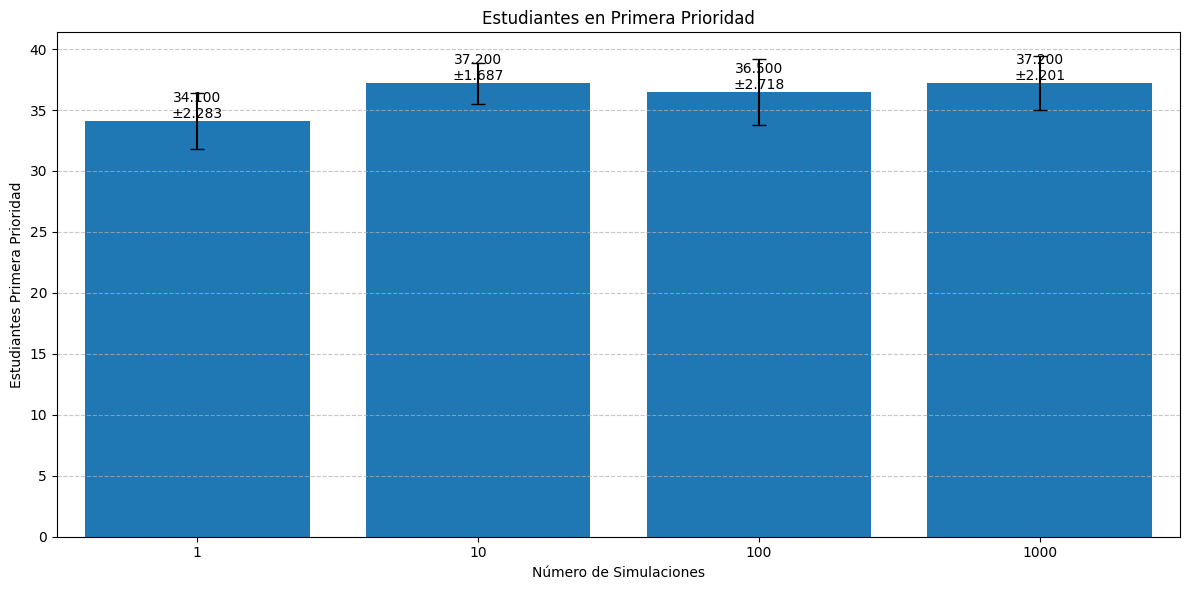

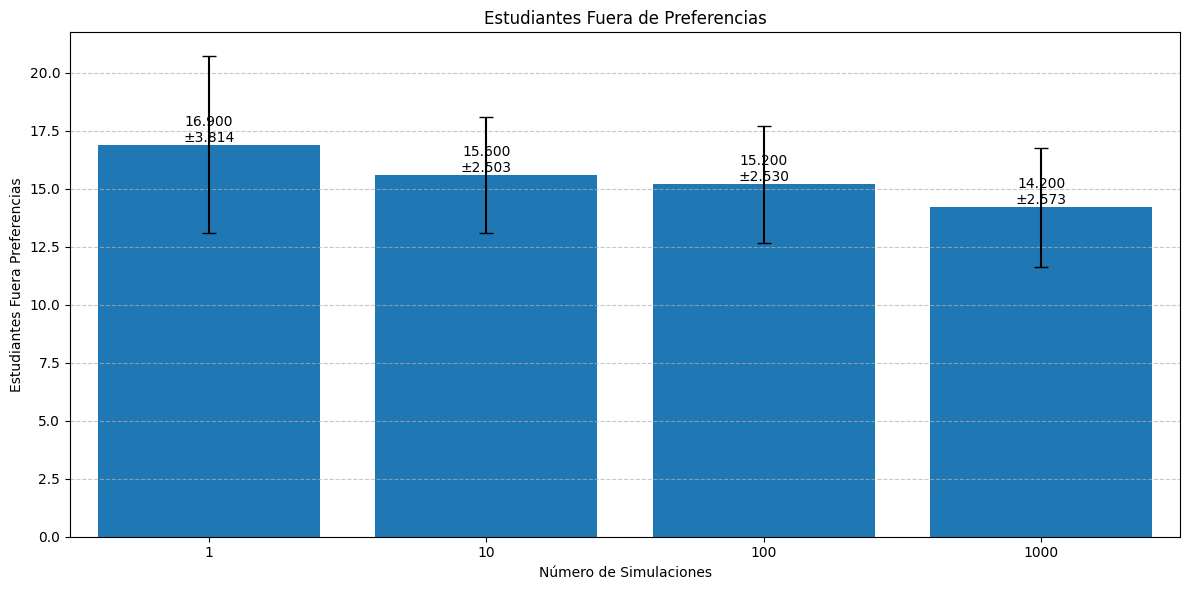

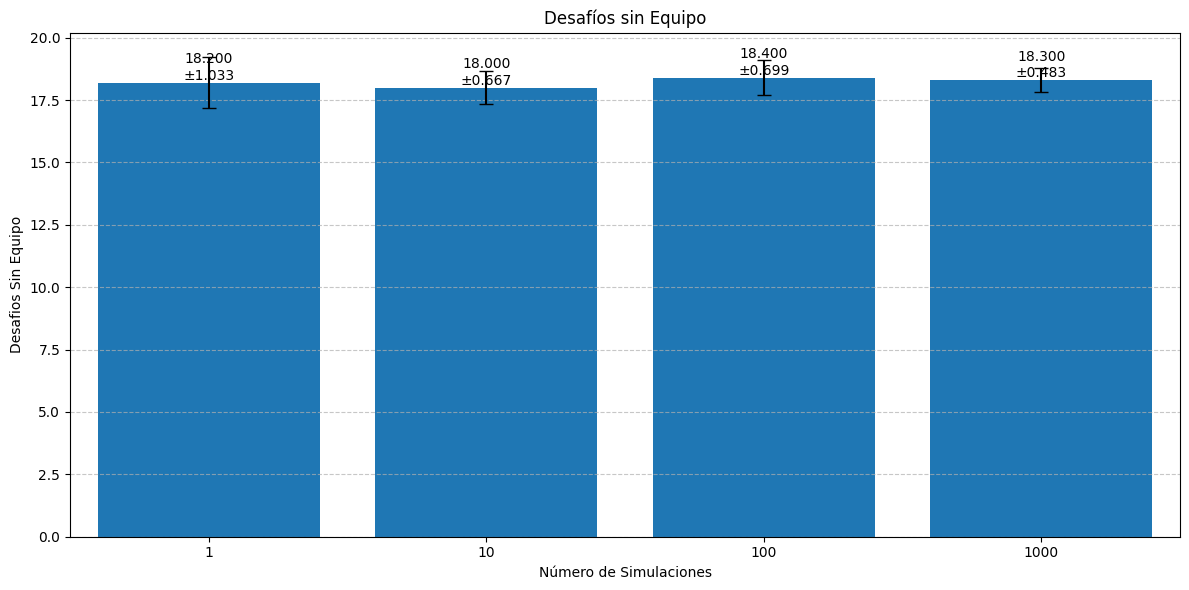

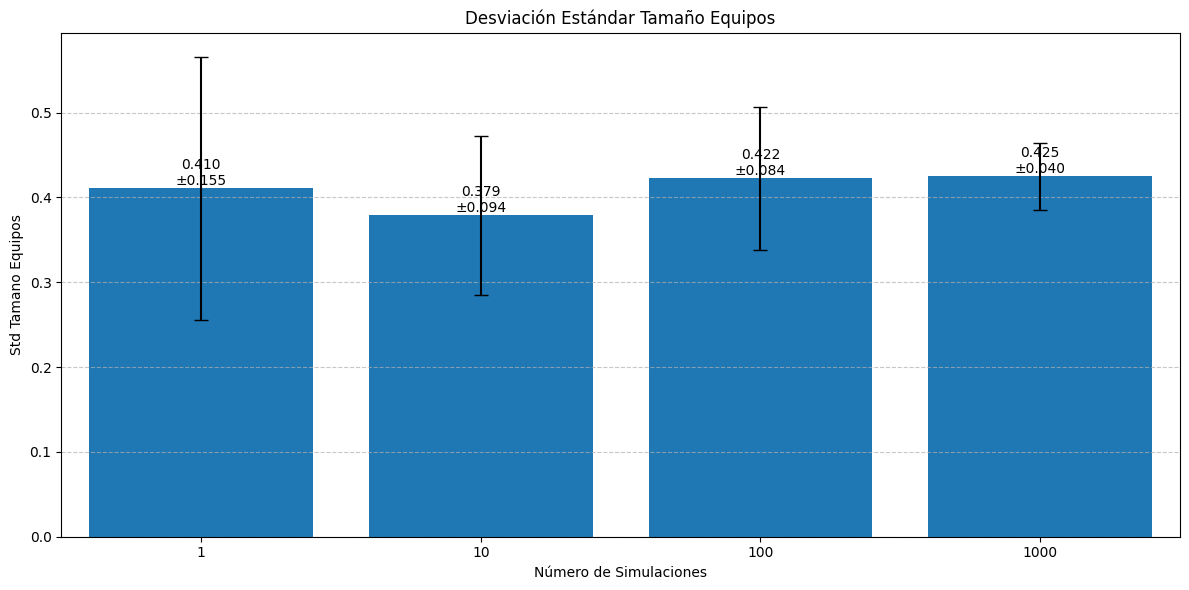

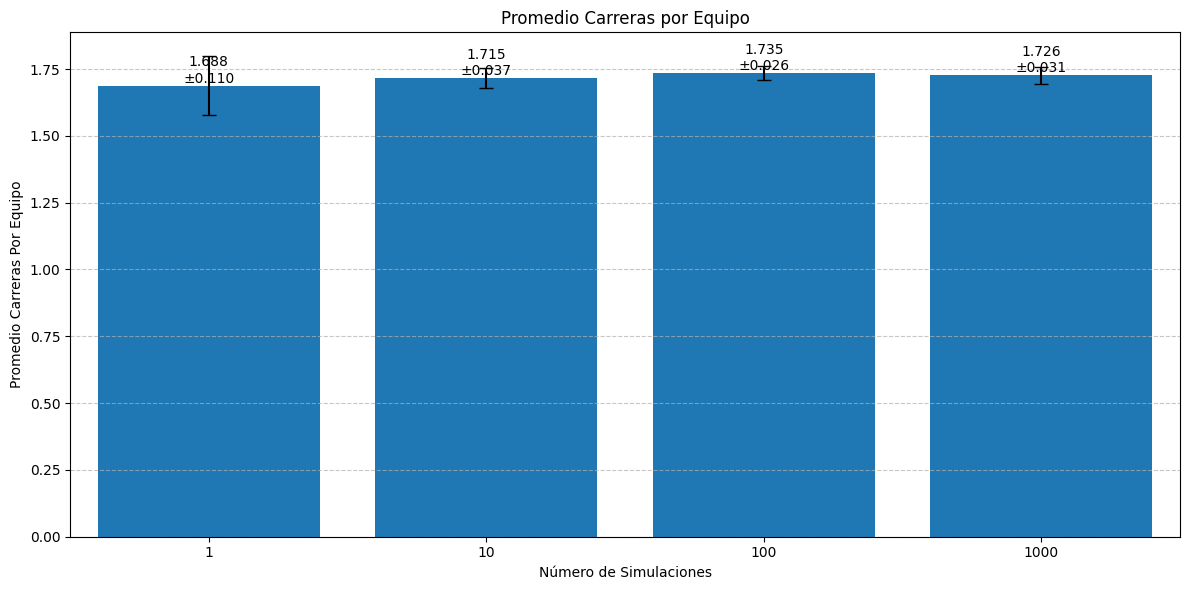

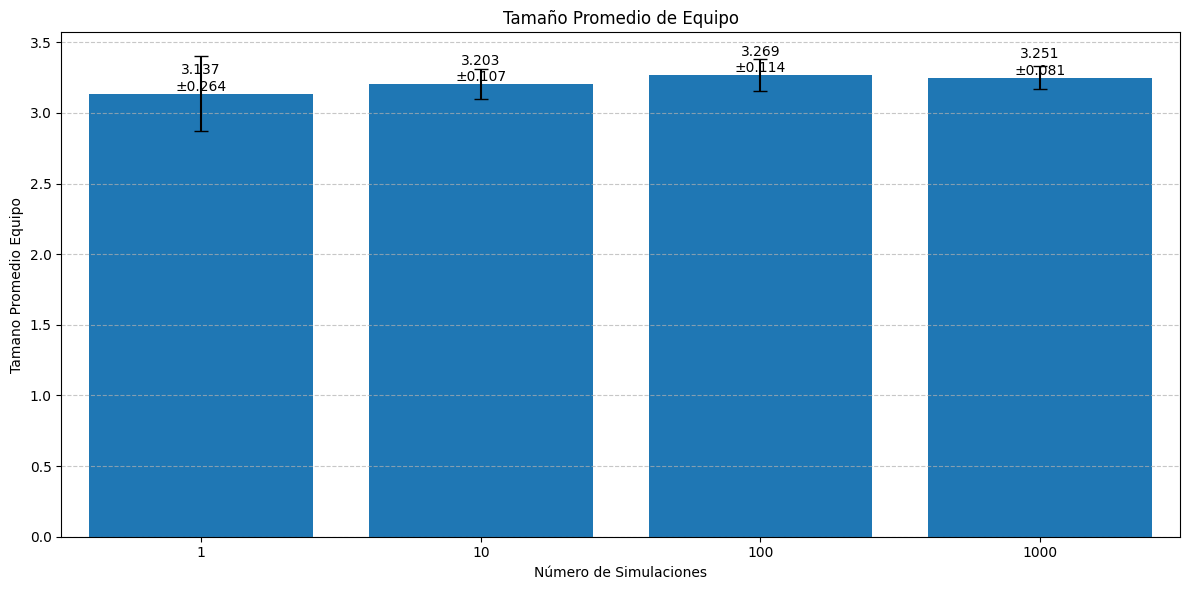

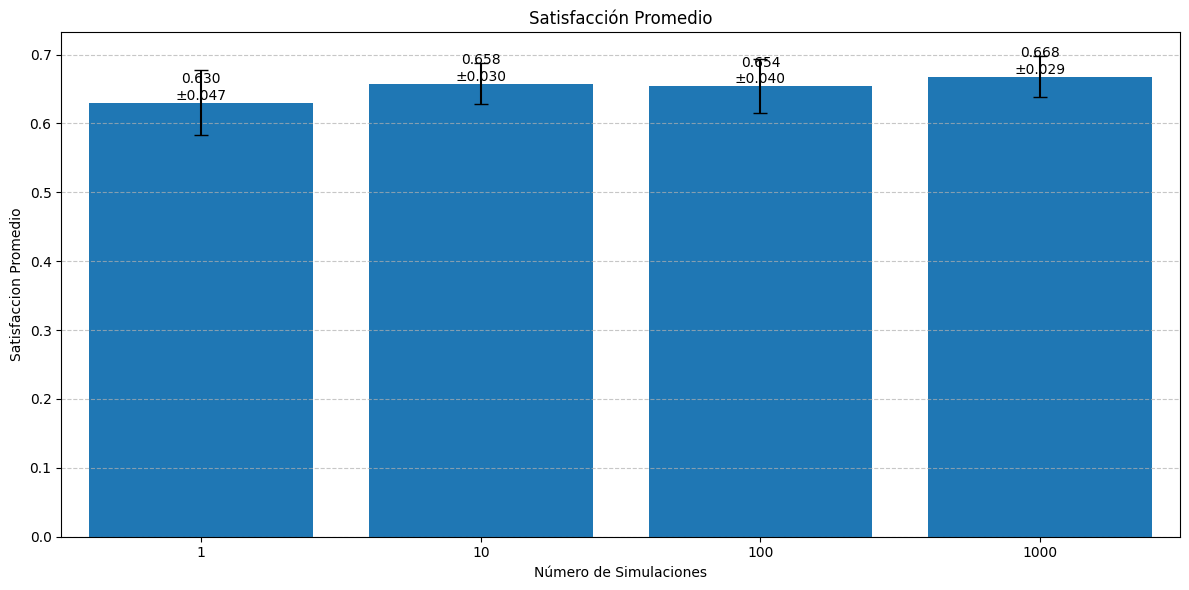

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Resultados guardados en results/random/mcts_analysis_results.csv


In [ ]:
# Ejecutar el análisis
results_df, averages_df, std_df, plots = run_analysis(body, "random")

# Para acceder a los resultados específicos
# print(averages_df['satisfaccion_promedio'])

save_results(results_df, "results/random/mcts_analysis_results.csv")

# Para guardar los gráficos
for metric, fig in plots.items():
    fig.savefig(f'results/random/{metric}_comparison.png')

## Desafio saturados

### ASC

Testing different distributions:   0%|          | 0/10 [00:00<?, ?it/s]

Testing different distributions: 100%|██████████| 10/10 [33:08<00:00, 198.80s/it]



=== Resumen de Resultados ===

Resultados promedio por número de simulaciones:
 Simulaciones Satisfaccion Promedio Estudiantes Primera Prioridad Estudiantes Fuera Preferencias Desafios Sin Equipo Std Tamano Equipos Promedio Carreras Por Equipo Tamano Promedio Equipo
            1         0.564 ± 0.018                   31.4 ± 1.35                   20.8 ± 1.687        17.4 ± 0.516      0.288 ± 0.097                 1.68 ± 0.017          3.109 ± 0.079
           10          0.608 ± 0.04                  34.4 ± 3.134                   17.9 ± 2.025        17.4 ± 0.516      0.288 ± 0.097                 1.68 ± 0.017          3.109 ± 0.079
          100         0.662 ± 0.017                  38.6 ± 1.713                   15.8 ± 1.033        17.7 ± 0.483       0.344 ± 0.09                 1.69 ± 0.016          3.154 ± 0.074
         1000         0.675 ± 0.016                  39.3 ± 0.823                   14.6 ± 1.075        17.1 ± 0.316      0.232 ± 0.059                 1.67 ± 0.011    

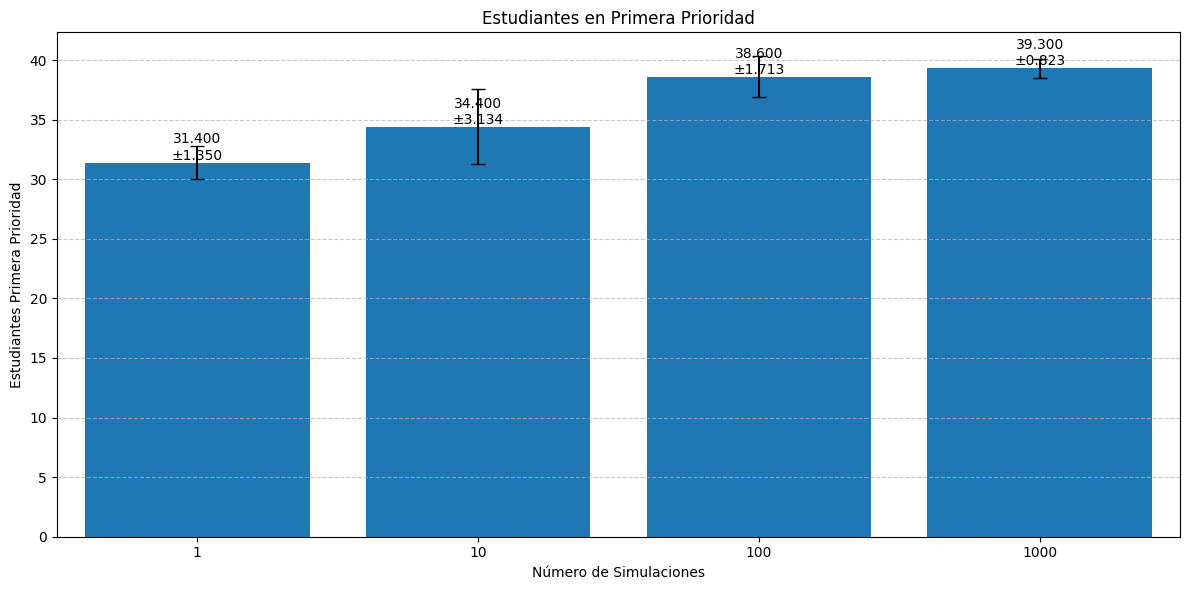

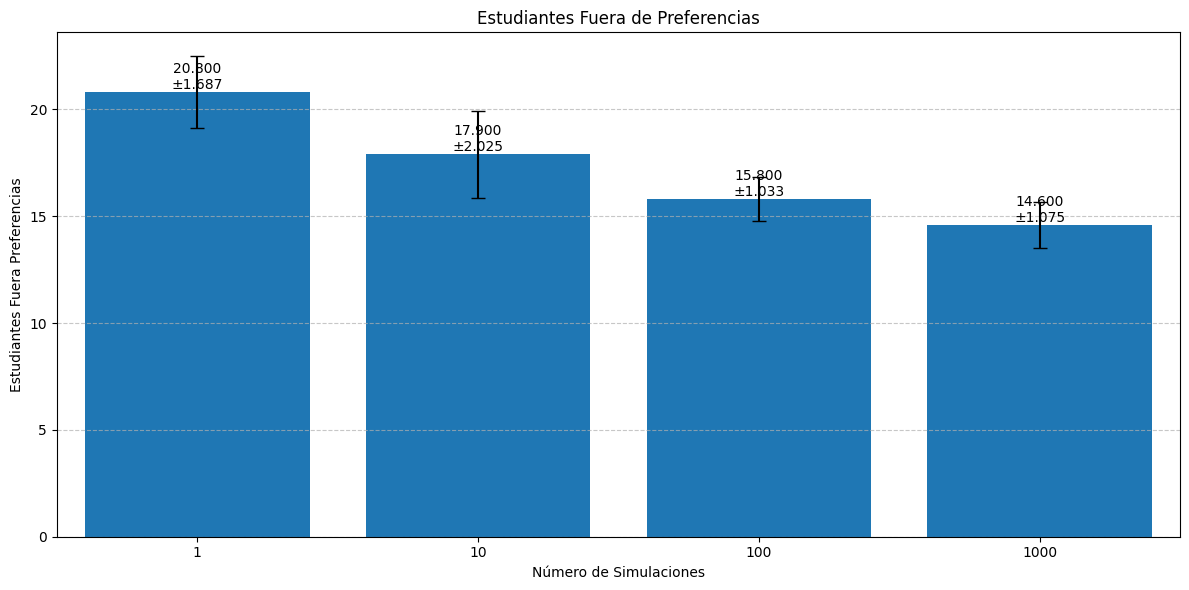

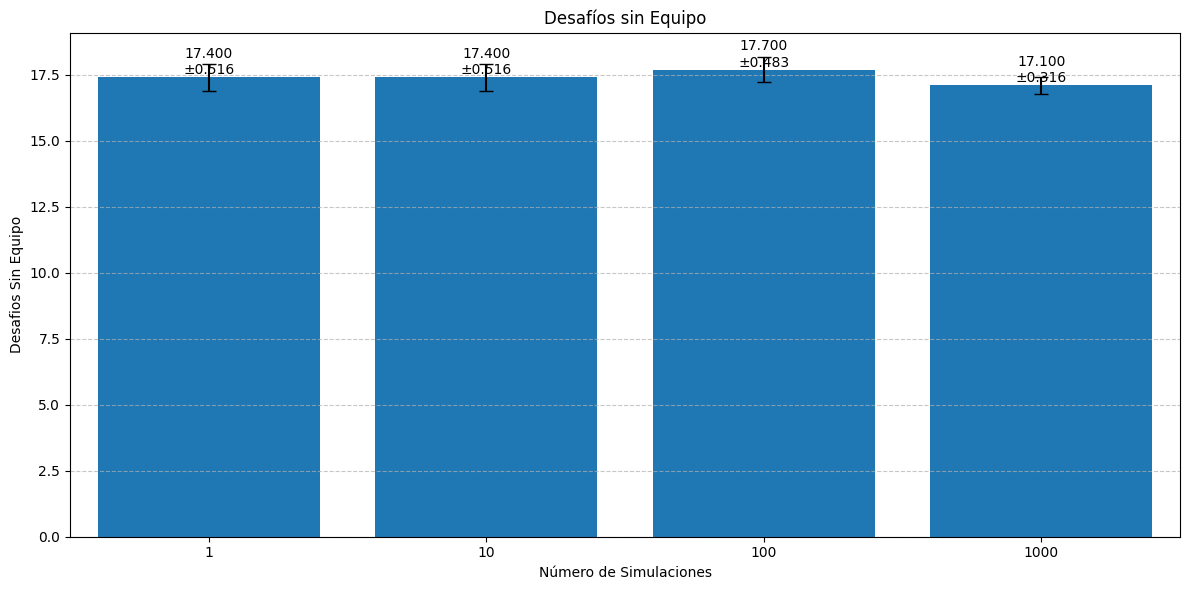

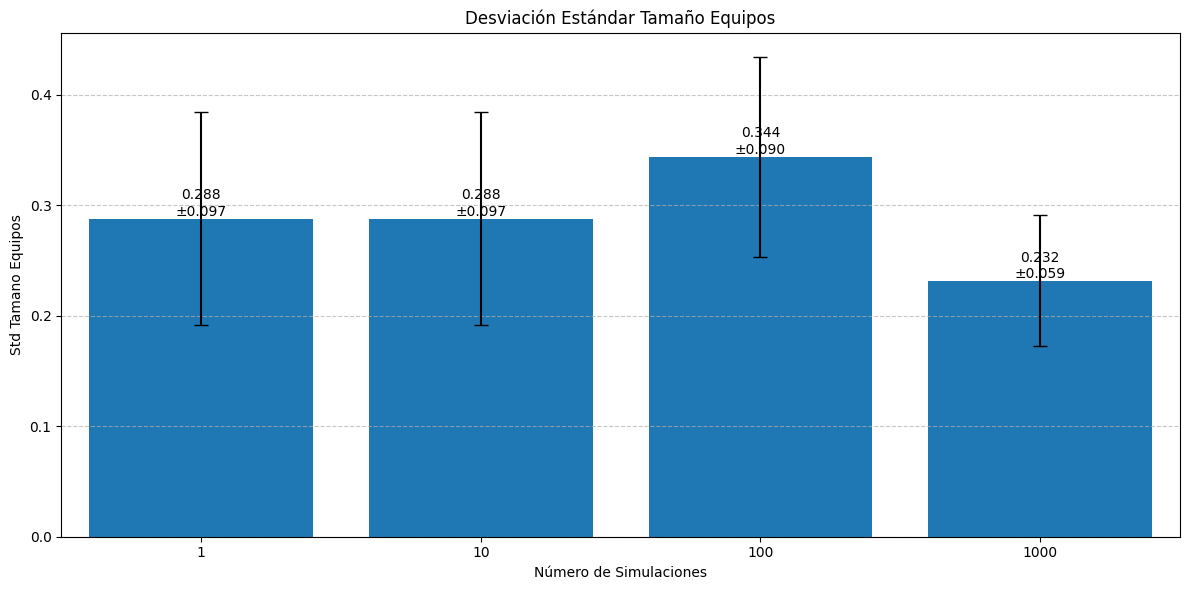

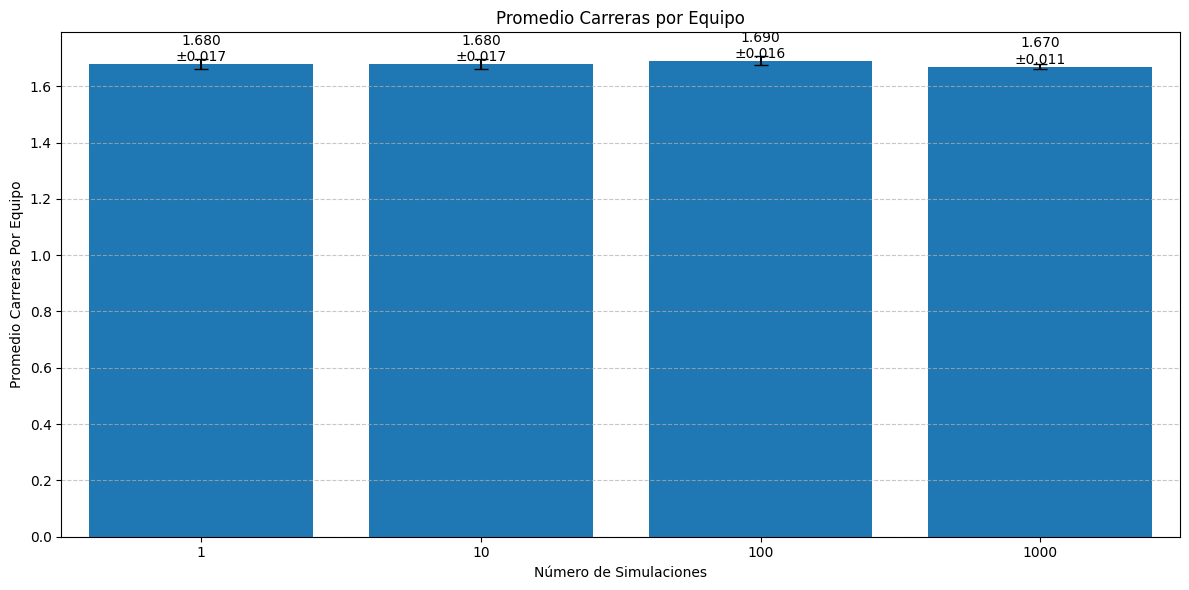

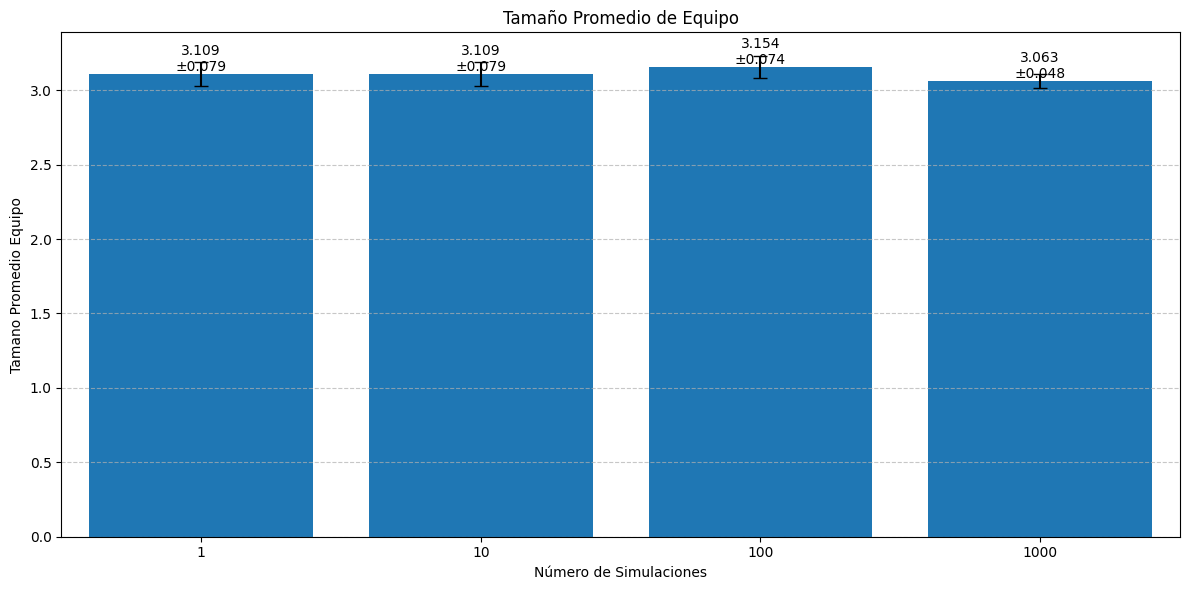

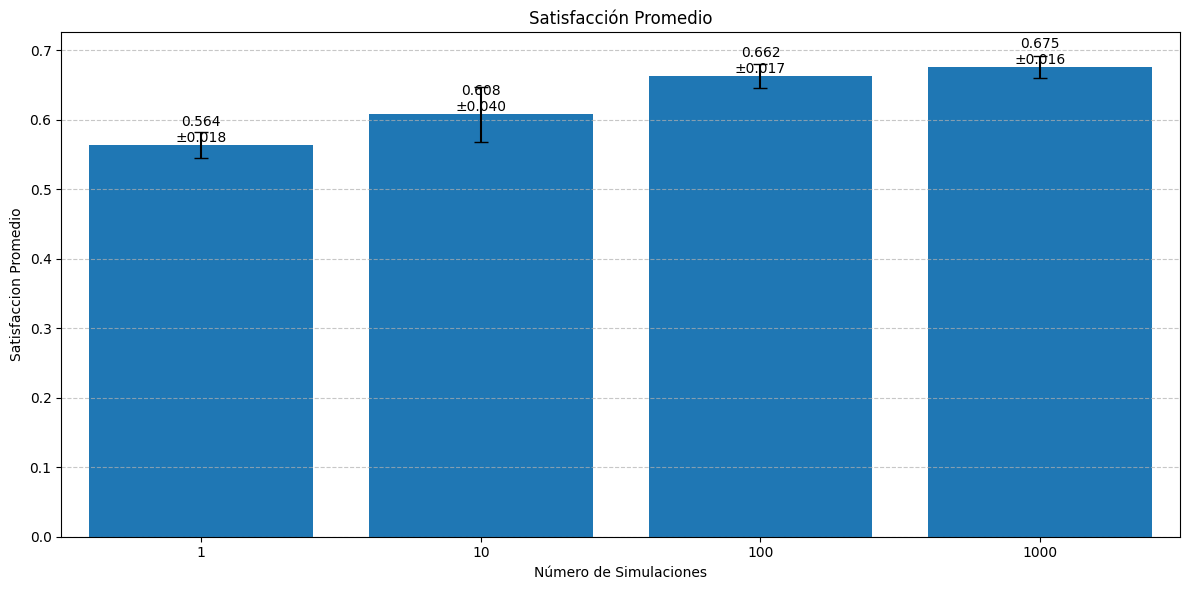

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Resultados guardados en results/desafios_saturados/asc/mcts_analysis_results.csv


In [10]:
# Ejecutar el análisis
results_df, averages_df, std_df, plots = run_analysis(body, experiment="challenge_saturation_asc")

# Para acceder a los resultados específicos
# print(averages_df['satisfaccion_promedio'])

save_results(results_df, "results/desafios_saturados/asc/mcts_analysis_results.csv")

# Para guardar los gráficos
for metric, fig in plots.items():
    fig.savefig(f'results/desafios_saturados/asc/{metric}_comparison.png')

### DESC

Testing different distributions: 100%|██████████| 10/10 [28:15<00:00, 169.60s/it]



=== Resumen de Resultados ===

Resultados promedio por número de simulaciones:
 Simulaciones Satisfaccion Promedio Estudiantes Primera Prioridad Estudiantes Fuera Preferencias Desafios Sin Equipo Std Tamano Equipos Promedio Carreras Por Equipo Tamano Promedio Equipo
            1          0.671 ± 0.02                  31.9 ± 1.729                    9.9 ± 1.912        18.5 ± 0.527       0.432 ± 0.08                1.672 ± 0.048           3.13 ± 0.123
           10         0.665 ± 0.026                  32.3 ± 1.059                   10.6 ± 3.062        18.4 ± 0.843      0.512 ± 0.123                1.664 ± 0.107          3.142 ± 0.179
          100         0.652 ± 0.026                  32.5 ± 1.716                   12.0 ± 2.108        18.6 ± 0.516       0.45 ± 0.043                1.742 ± 0.033           3.28 ± 0.094
         1000         0.644 ± 0.024                  31.9 ± 1.524                   12.4 ± 1.838        18.1 ± 0.316      0.408 ± 0.026                1.744 ± 0.026    

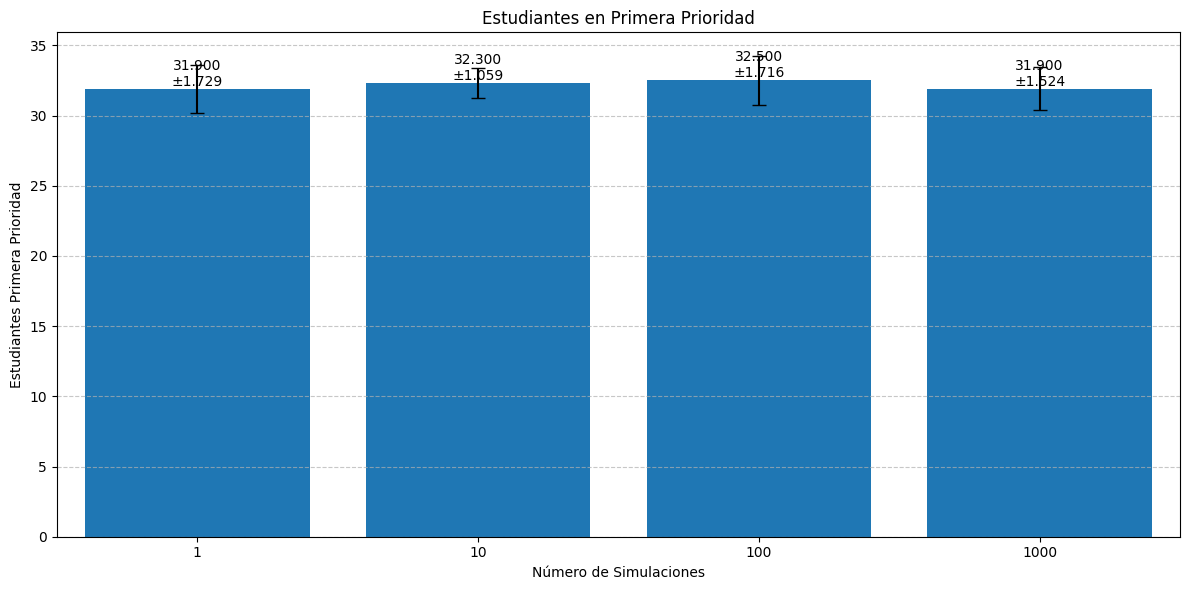

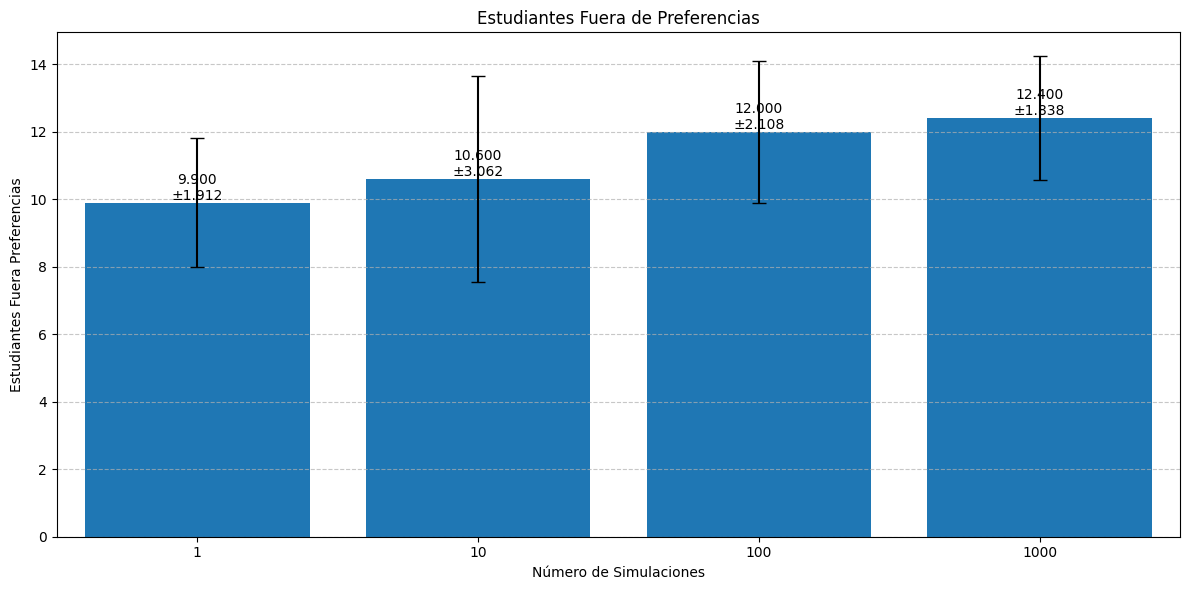

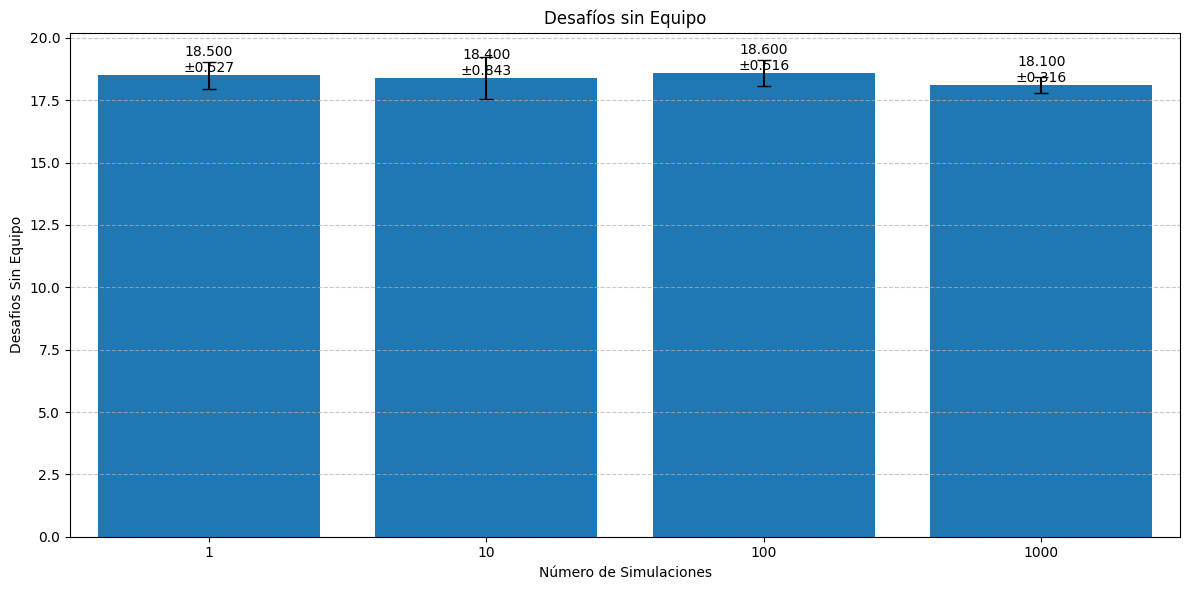

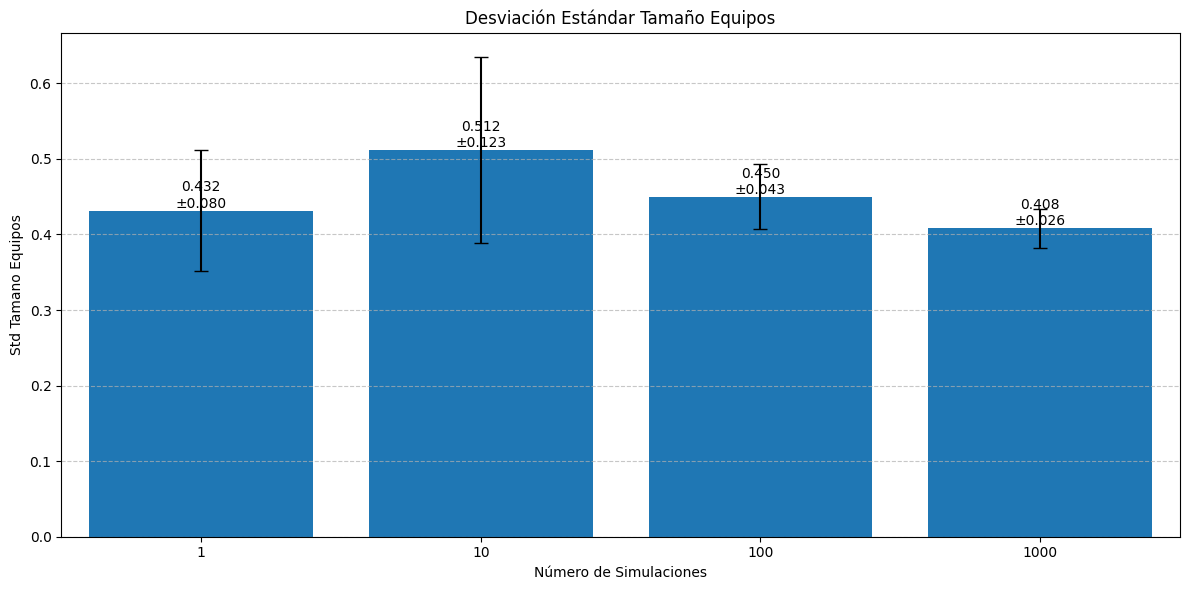

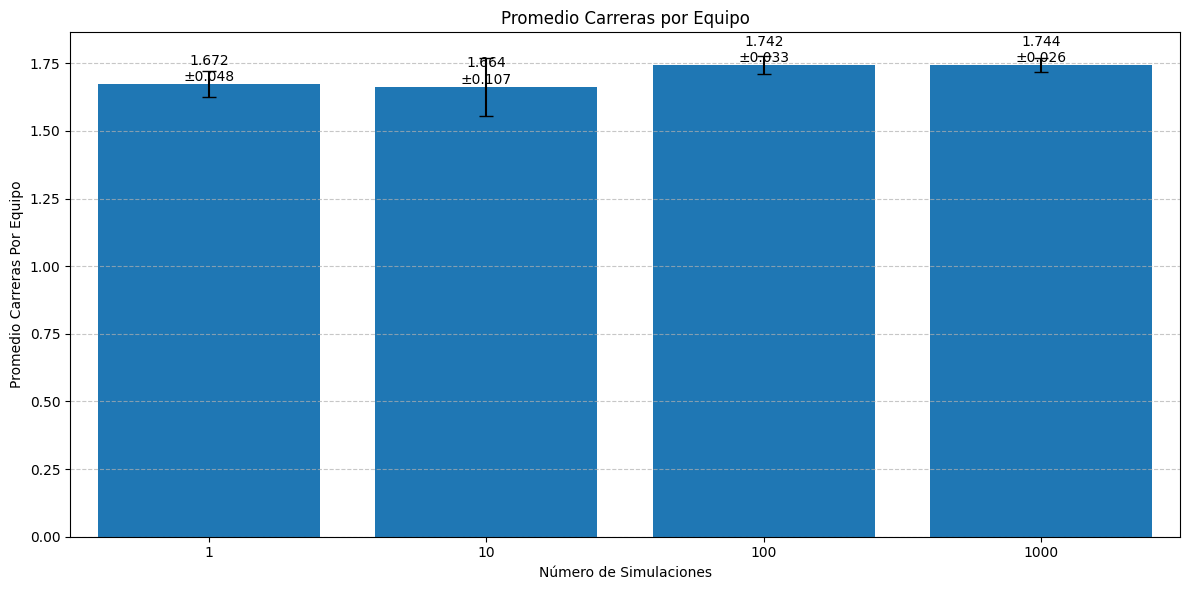

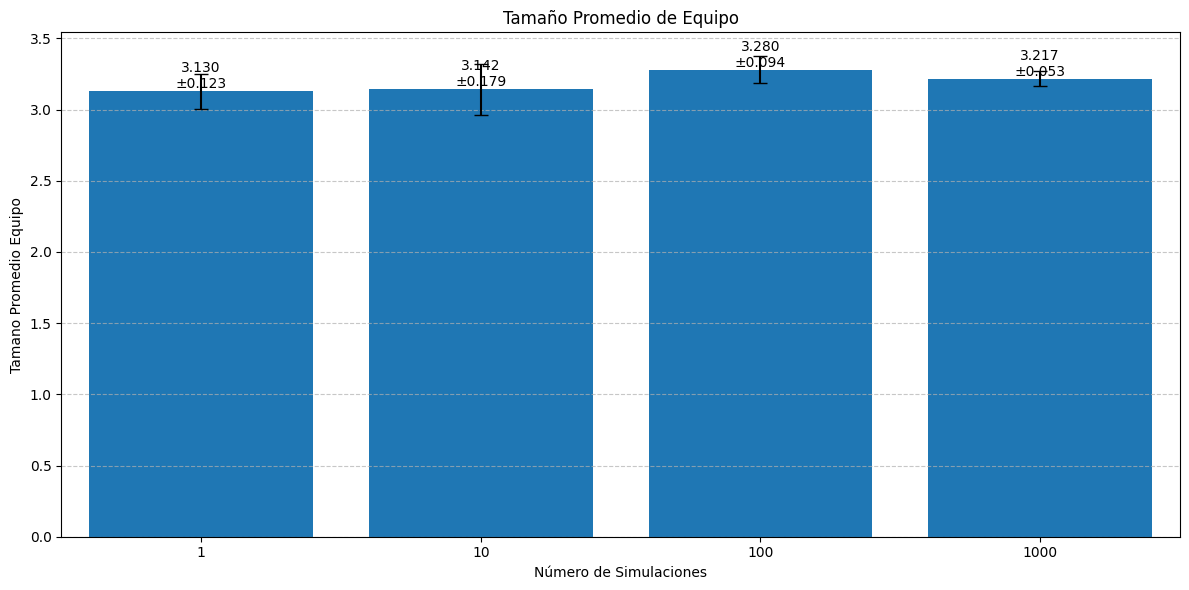

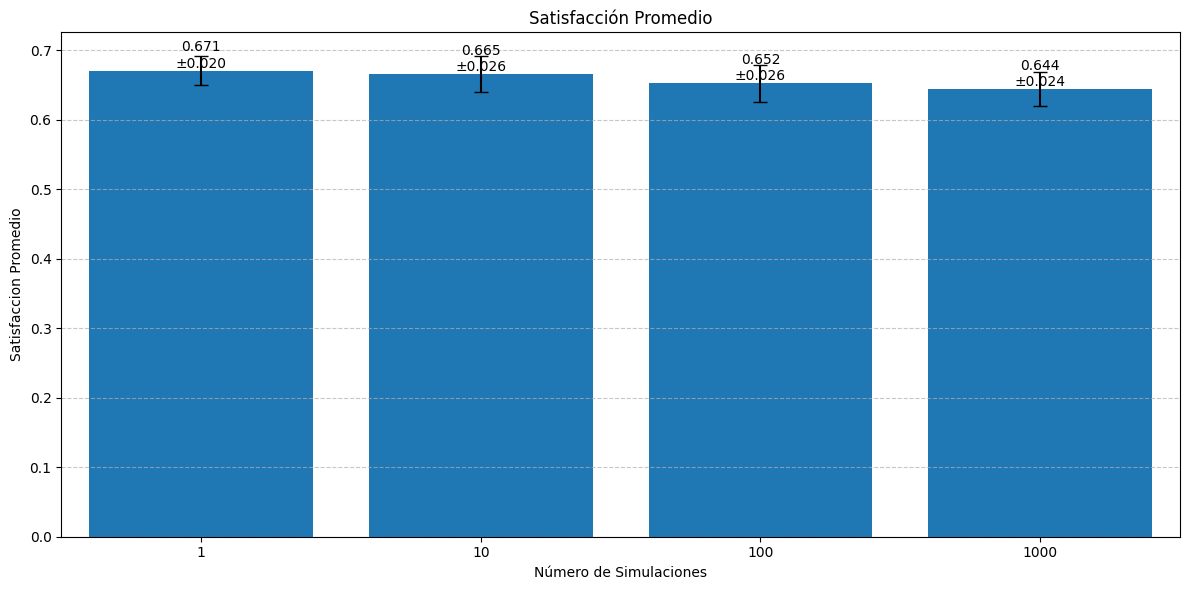

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Resultados guardados en results/desafios_saturados/desc/mcts_analysis_results.csv


In [11]:
# Ejecutar el análisis
results_df, averages_df, std_df, plots = run_analysis(body, experiment="challenge_saturation_desc")

# Para acceder a los resultados específicos
# print(averages_df['satisfaccion_promedio'])

save_results(results_df, "results/desafios_saturados/desc/mcts_analysis_results.csv")

# Para guardar los gráficos
for metric, fig in plots.items():
    fig.savefig(f'results/desafios_saturados/desc/{metric}_comparison.png')

## Tamaño de carreras

### ASC

Testing different distributions: 100%|██████████| 10/10 [32:47<00:00, 196.79s/it]



=== Resumen de Resultados ===

Resultados promedio por número de simulaciones:
 Simulaciones Satisfaccion Promedio Estudiantes Primera Prioridad Estudiantes Fuera Preferencias Desafios Sin Equipo Std Tamano Equipos Promedio Carreras Por Equipo Tamano Promedio Equipo
            1          0.61 ± 0.023                    35.0 ± 1.7                   19.7 ± 1.494        19.1 ± 0.316      0.484 ± 0.005                1.741 ± 0.013          3.387 ± 0.059
           10         0.641 ± 0.017                  36.5 ± 0.972                    16.9 ± 1.37        18.8 ± 0.422      0.466 ± 0.035                1.729 ± 0.016          3.335 ± 0.071
          100         0.646 ± 0.019                  37.1 ± 1.449                   16.8 ± 1.033        18.9 ± 0.316      0.474 ± 0.026                1.733 ± 0.012          3.352 ± 0.053
         1000         0.647 ± 0.021                  37.2 ± 1.549                   16.6 ± 0.966          19.0 ± 0.0        0.482 ± 0.0                  1.737 ± 0.0    

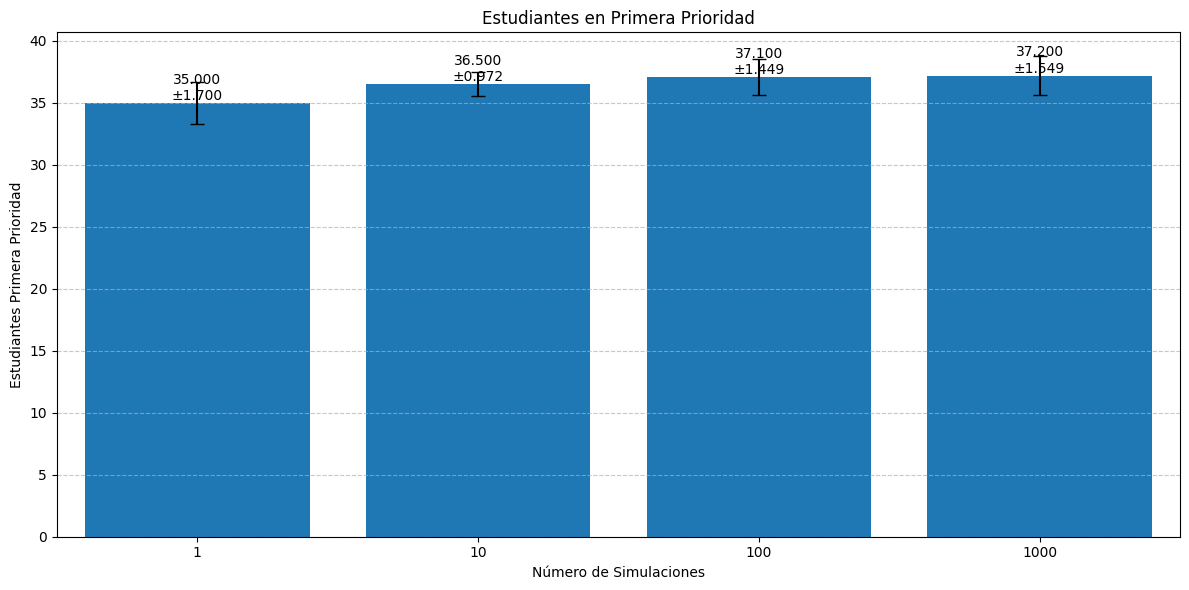

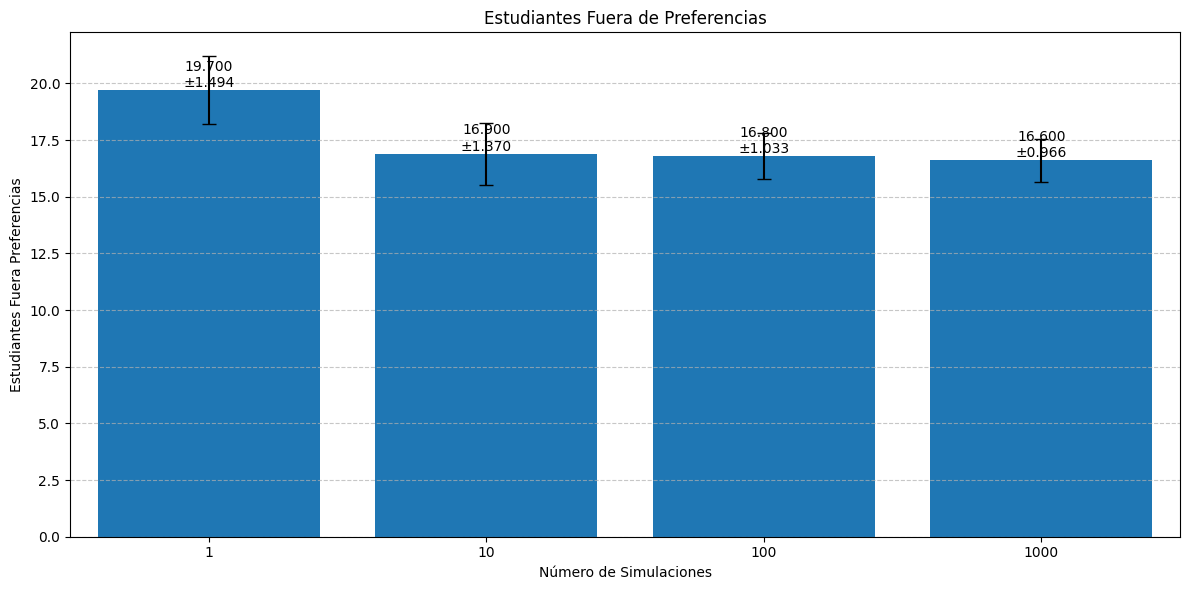

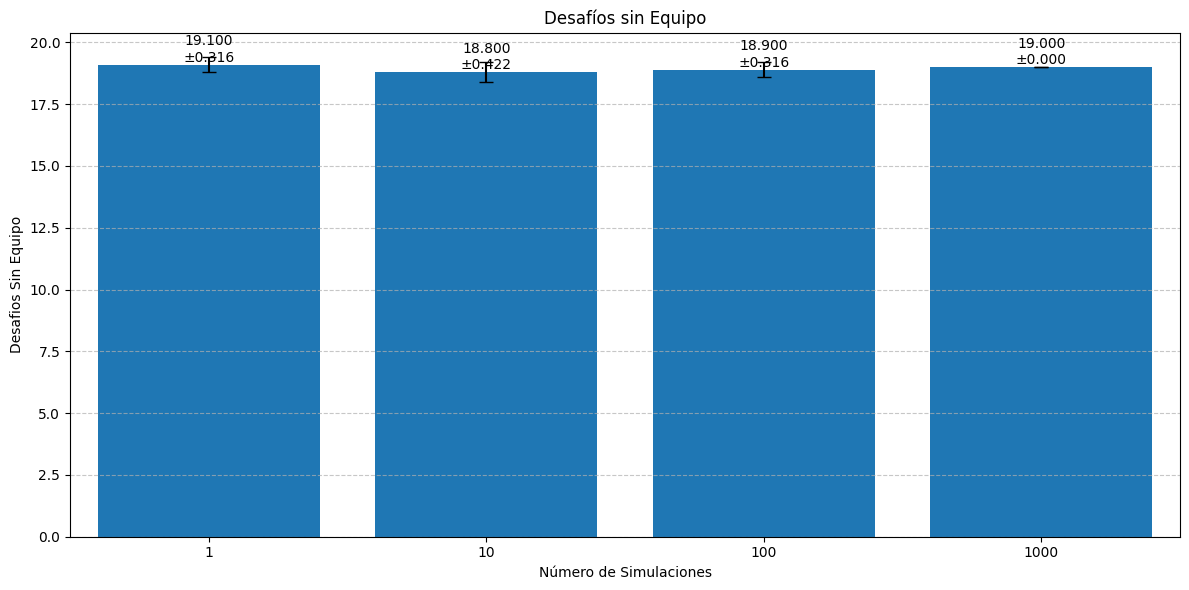

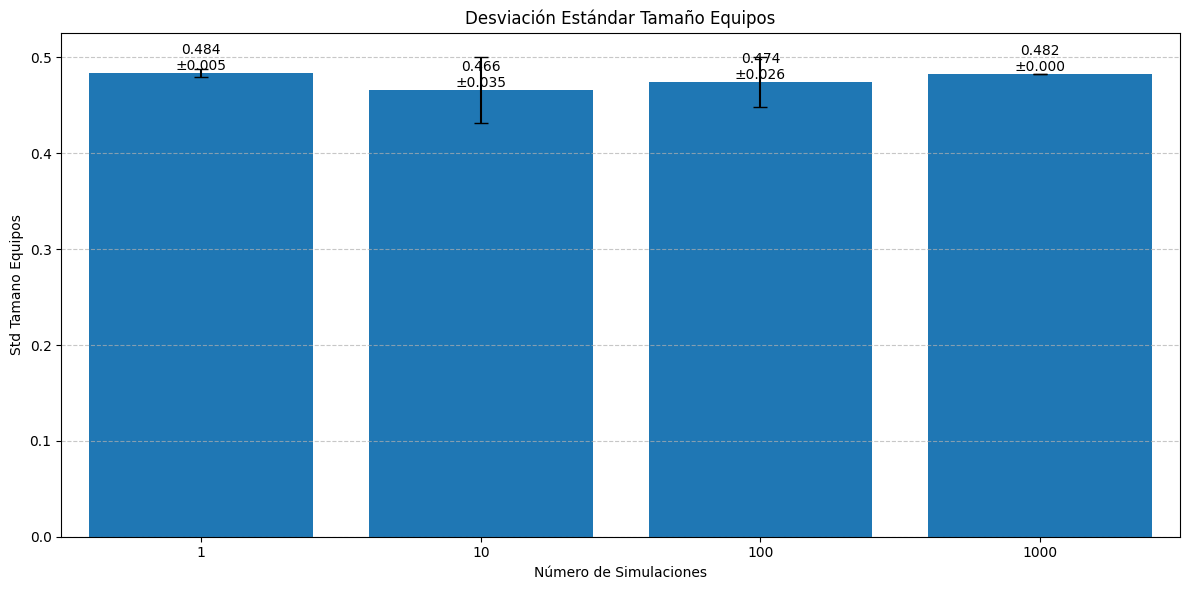

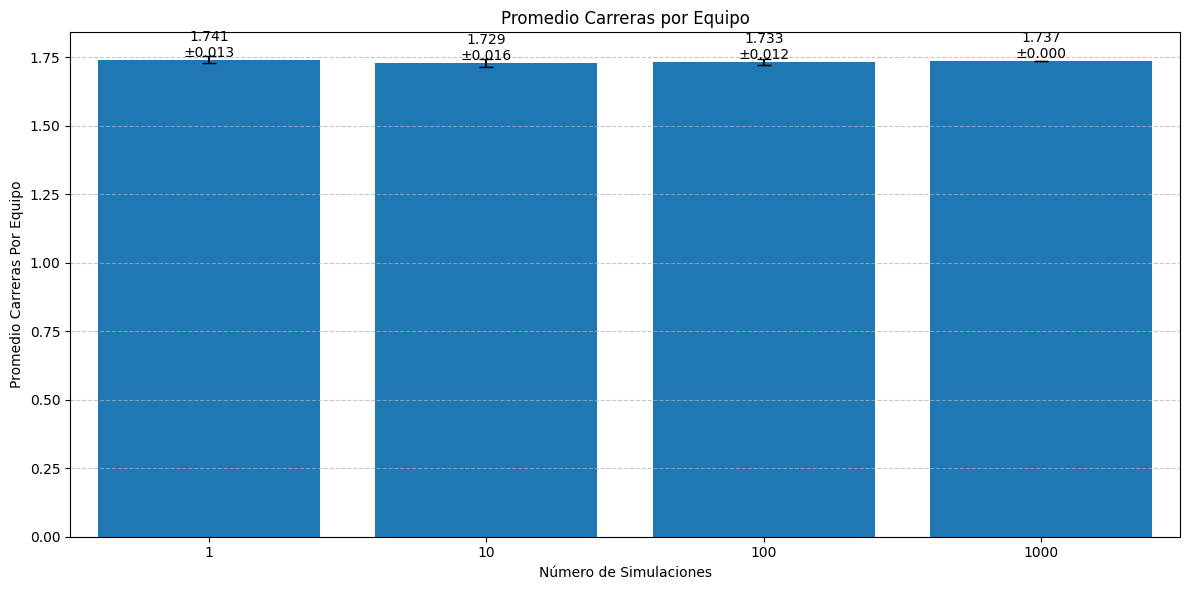

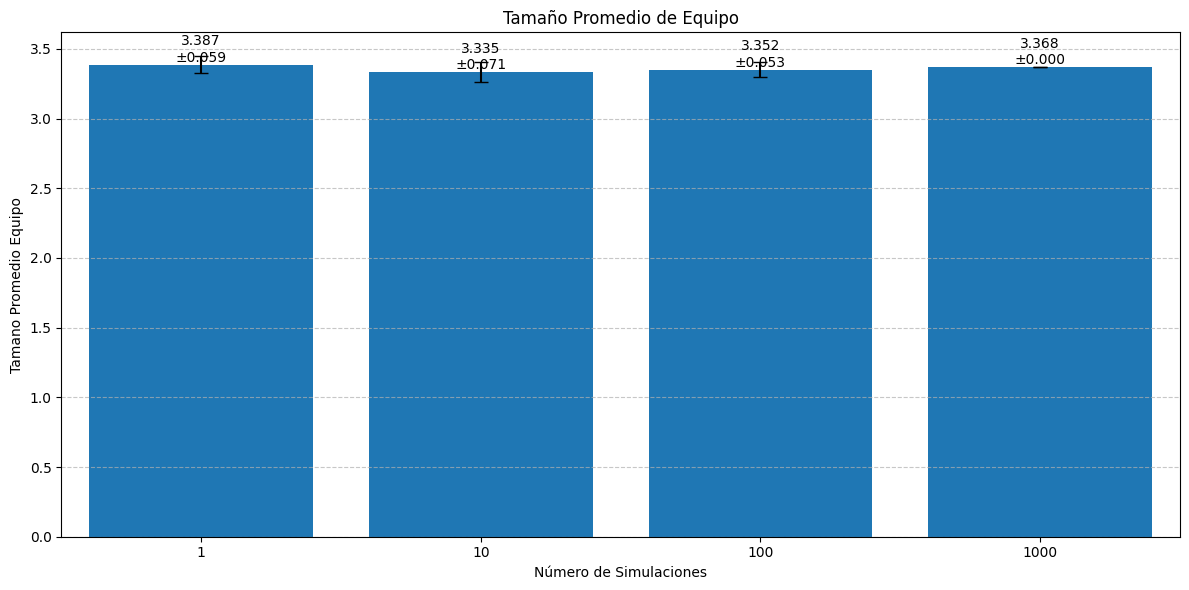

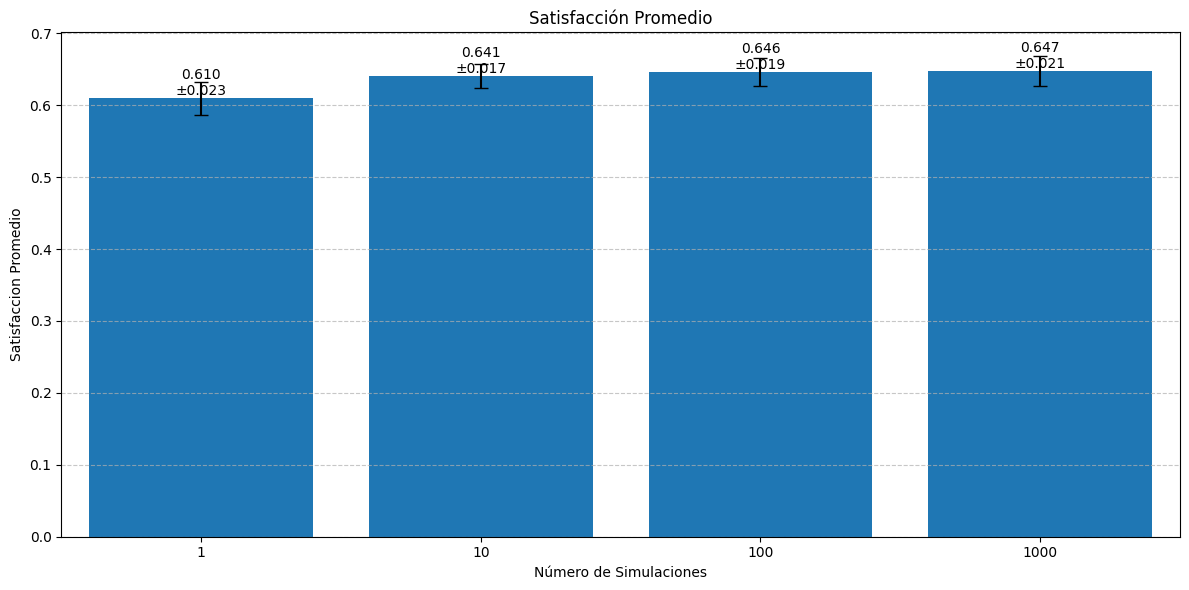

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Resultados guardados en results/tamaño_carreras/asc/mcts_analysis_results.csv


In [12]:
# Ejecutar el análisis
results_df, averages_df, std_df, plots = run_analysis(body, experiment="career_size_asc")

# Para acceder a los resultados específicos
# print(averages_df['satisfaccion_promedio'])

save_results(results_df, "results/tamaño_carreras/asc/mcts_analysis_results.csv")

# Para guardar los gráficos
for metric, fig in plots.items():
    fig.savefig(f'results/tamaño_carreras/asc/{metric}_comparison.png')

### DESC

Testing different distributions: 100%|██████████| 10/10 [27:29<00:00, 164.98s/it]



=== Resumen de Resultados ===

Resultados promedio por número de simulaciones:
 Simulaciones Satisfaccion Promedio Estudiantes Primera Prioridad Estudiantes Fuera Preferencias Desafios Sin Equipo Std Tamano Equipos Promedio Carreras Por Equipo Tamano Promedio Equipo
            1           0.7 ± 0.025                  34.8 ± 1.476                    11.2 ± 2.44        18.3 ± 0.675      0.508 ± 0.115                1.402 ± 0.162          2.932 ± 0.206
           10         0.711 ± 0.024                  38.4 ± 3.777                   11.9 ± 2.767        18.5 ± 0.527      0.444 ± 0.051                1.582 ± 0.201          3.122 ± 0.256
          100         0.699 ± 0.018                  39.7 ± 2.003                   13.2 ± 1.135        18.7 ± 0.483       0.458 ± 0.04                1.726 ± 0.036          3.318 ± 0.081
         1000         0.708 ± 0.006                  39.6 ± 0.516                   12.2 ± 0.789        18.3 ± 0.483       0.425 ± 0.04                1.676 ± 0.042    

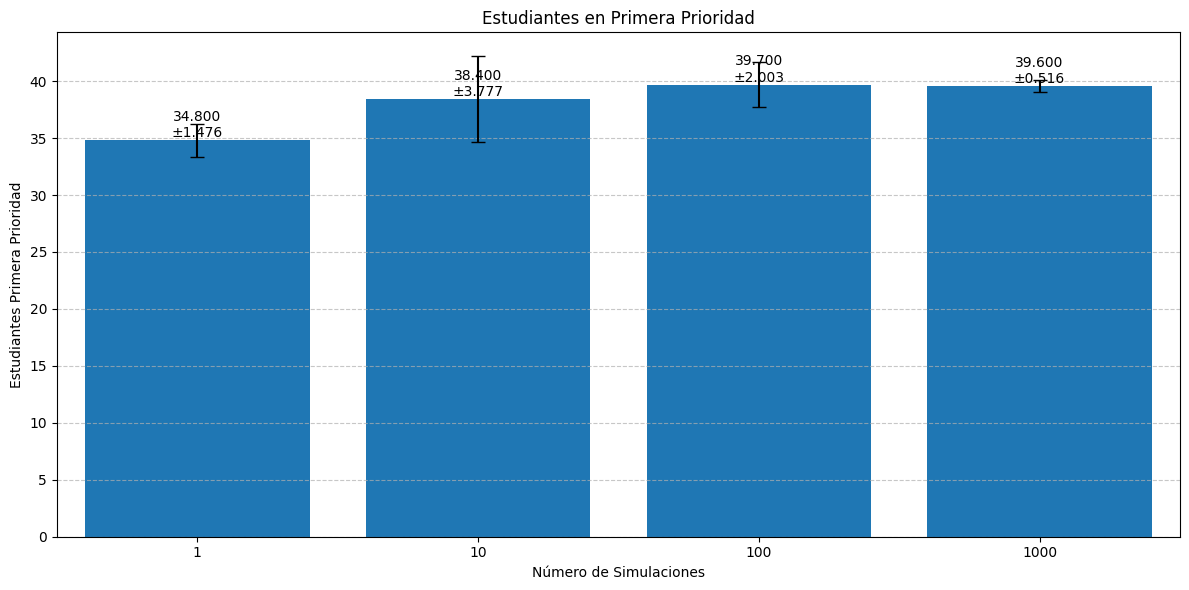

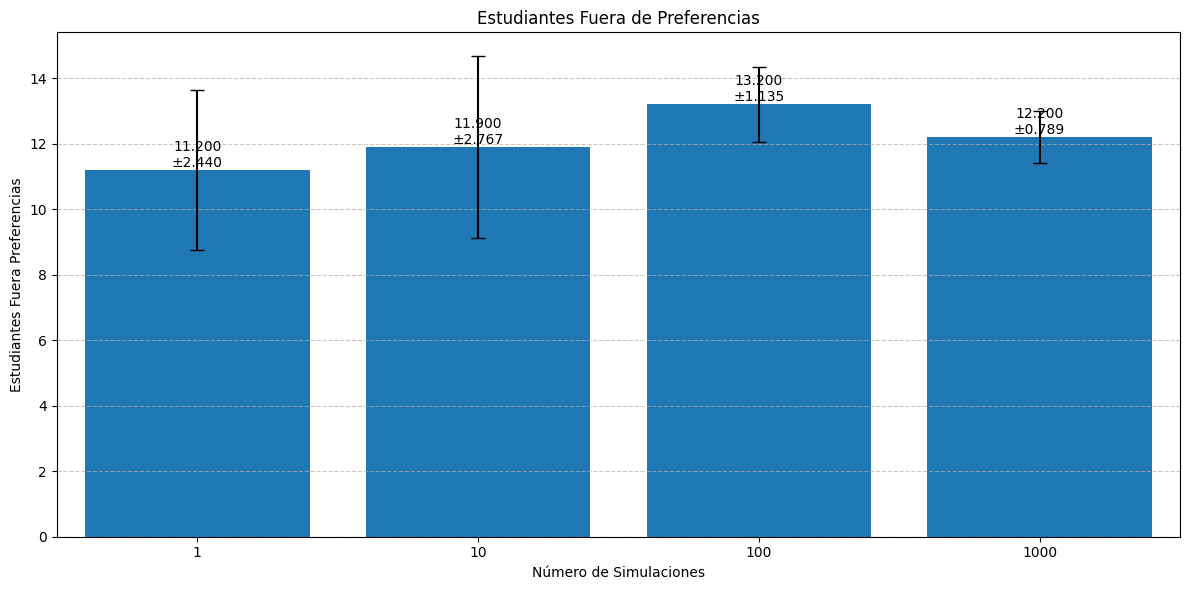

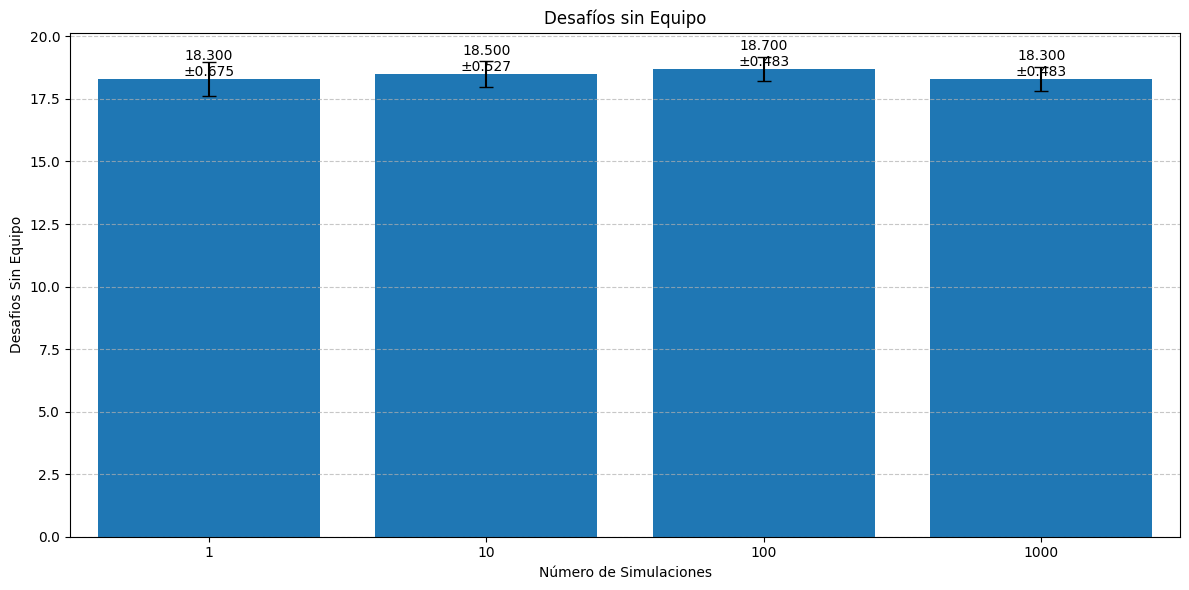

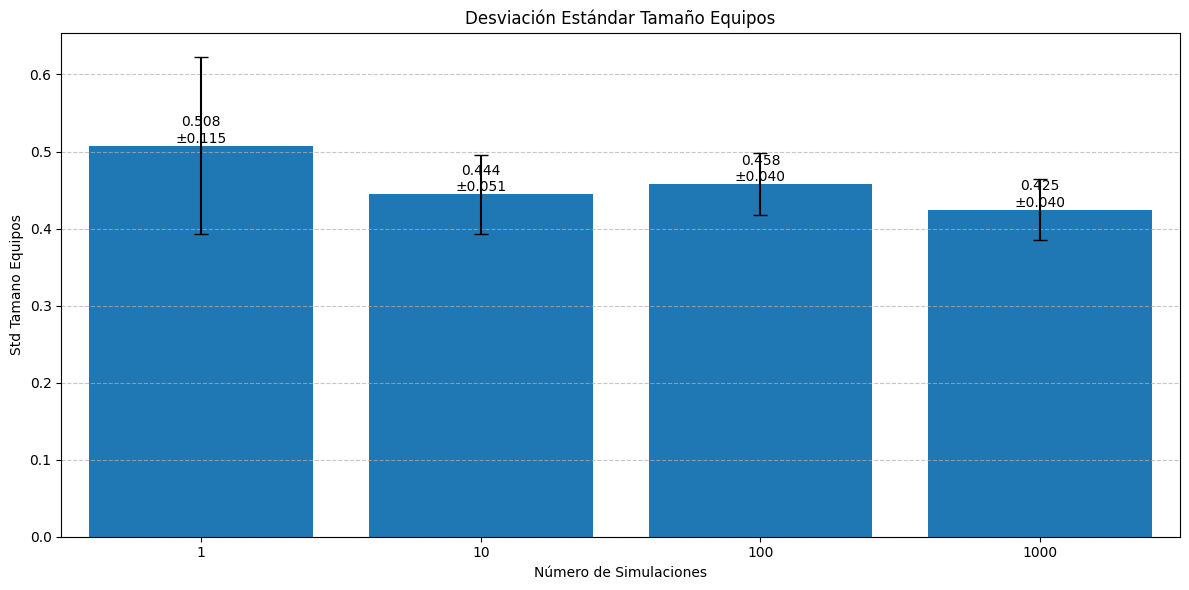

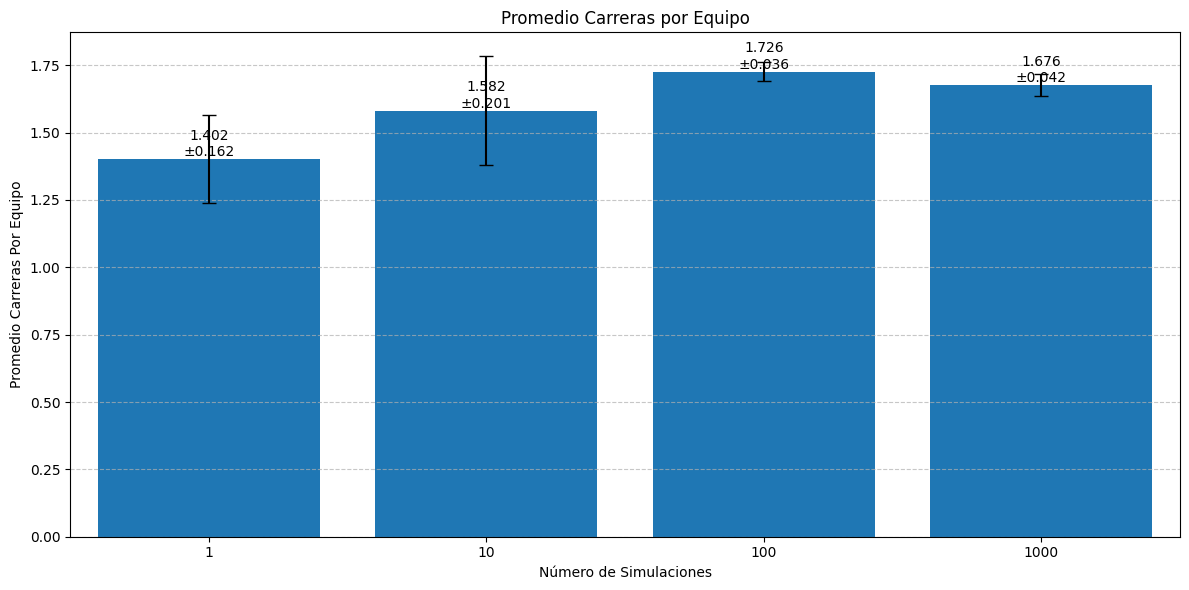

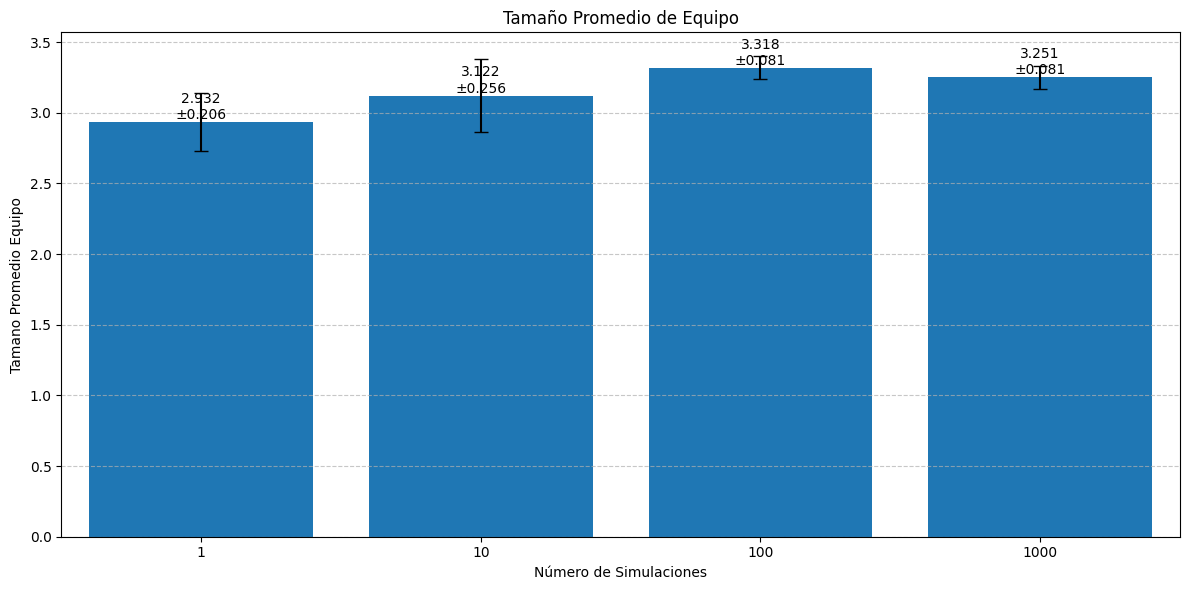

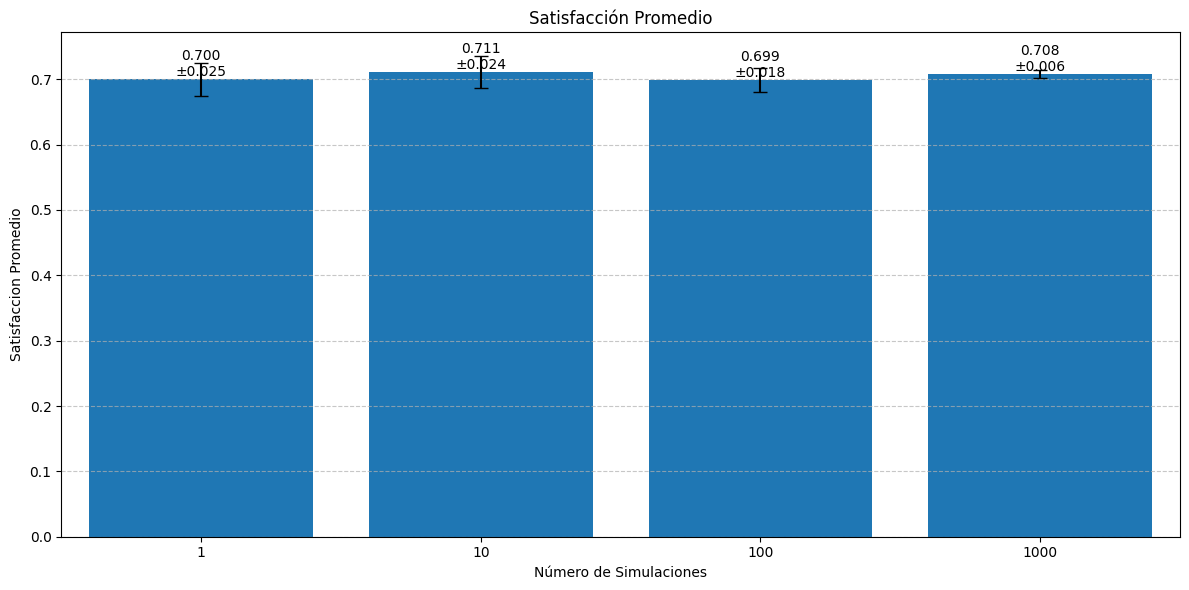

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Resultados guardados en results/tamaño_carreras/desc/mcts_analysis_results.csv


In [13]:
# Ejecutar el análisis
results_df, averages_df, std_df, plots = run_analysis(body, experiment="career_size_desc")

# Para acceder a los resultados específicos
# print(averages_df['satisfaccion_promedio'])

save_results(results_df, "results/tamaño_carreras/desc/mcts_analysis_results.csv")

# Para guardar los gráficos
for metric, fig in plots.items():
    fig.savefig(f'results/tamaño_carreras/desc/{metric}_comparison.png')